# Multi-scale VSWIR Imaging Spectroscopy for Critical-Mineral Indicators
## Southern Pine Valley area, southern Wah Wah Range, Beaver County, Utah (Utah Geological Survey AOI)

A tutorial for the SEG critical-minerals session.

This version targets an area of interest (AOI) defined by the **Utah Geological Survey (UGS)** in
the **Southern Pine Valley area** of the southern Wah Wah Range, Beaver County, Utah, where the UGS
holds associated surface **geochemistry** data. The AOI (`data/AOI/AOI.shp`) is co-located with the
UGS 1:24,000-scale geologic map of the area, **Open-File Report 671 (OFR-671)**, whose geologic-unit
polygons we bring in below (section 1.1) to frame the study area.

Visible-to-shortwave-infrared (VSWIR, ~0.38-2.5 µm) imaging spectroscopy measures the
diagnostic molecular absorption features of surface minerals. This tutorial shows how the
same spectral physics is exploited at two spatial scales to find surface indicators of
critical minerals:

| Scale | Sensor | Pixel | Role in this tutorial |
|-------|--------|-------|-----------------------|
| Spaceborne | EMIT (ISS) | ~60 m | Regional screening. We use the L2B mineralogy (L2BMIN) product to map alunite, white mica, kaolinite, pyrophyllite, dickite over the AOI. |
| Airborne | AVIRIS-5 | ~10 m (this flight line) | Outcrop-scale confirmation. We pull L2A surface reflectance and characterize the diagnostic absorption features that drive the mineral identifications. |

A note on AVIRIS-5 pixel size. AVIRIS-5 is an airborne sensor, so its ground sampling distance
(GSD) is set by the aircraft's height above the surface, not by a fixed orbit like EMIT. Across
typical AVIRIS-5 campaigns the delivered GSD ranges from roughly 0.5 m to 15 m. We read and confirm
the exact GSD of the flight lines used here directly from the files in section 5, so the
EMIT-to-AVIRIS resolution ratio is measured, not assumed.

### Why this area? A lithophile critical-metal system in evolved rhyolite
The Southern Pine Valley AOI (southern Wah Wah Range, Beaver County, UT ~ 38.12° N, 113.61° W) sits
on the Pioche mineral belt / Blue Ribbon lineament. As the UGS OFR-671 geologic map (section 1.1)
shows, the AOI exposes a broad stratigraphy - from Cambrian through Devonian carbonates, the
Oligocene Needles Range Group ash-flow tuffs, and the Miocene **Blawn Formation** rhyolites - and
it is the Blawn Formation that carries the critical-metal story. These are highly-evolved, A-type
rhyolites (the ~22.1 Ma Red Beryl Rhyolite and ~18.3 Ma Tetons Rhyolite; Barkoff, 2022): textbook
lithophile / critical-metal magmas that concentrate Be, Li, Mo, Sn, W, REE, U and F, carry accessory
fluorite plus REE phases (cerianite-Ce, allanite, monazite, xenotime), and are literally named for
their red beryl (bixbite). Historic work in the district (Lindsey & Osmonson, 1978, USGS OFR 78-114)
reported anomalous U, Sn (cassiterite up to ~3,000 ppm), Mo (up to ~150 ppm), Be, and Li (up to
~230 ppm) - and, notably, analysed for gold and found none at surface. This is a lithophile
suite hosted in evolved felsic rock, comparable to the Spor Mountain, UT beryllium belt and the
Climax, CO Mo system, not a gold-silver epithermal district.

### The alteration system: a pH gradient you can map spectrally
The reason spectroscopy works so well here is the alteration zonation, which is a map of the
mineralizing fluid's pH (Lindsey & Osmonson, 1978):

- An acidic, advanced-argillic cap (alunite + kaolinite + iron oxide + silicified breccia,
  developed in the rhyolites), the classic alunite lithocap.
- Grading into near-neutral to alkaline alteration (montmorillonite + illite + fluorite) around
  intrusive topaz rhyolite (past uranium + fluorspar production at the Staats mine).

That acidic to near-neutral transition is recorded in the mineralogy - alunite in the acidic
core, white micas (muscovite/illite) of shifting composition in the less-acidic halo - and it is
exactly what VSWIR spectroscopy can read.

### The spectral lever: the Al-OH feature near 2.2 µm
- Alunite: broad Al-OH at ~2.16-2.17 µm (plus a secondary feature ~2.32 µm).
- Pyrophyllite: sharp/narrow Al-OH at ~2.166 µm (width distinguishes it from alunite).
- Kaolinite / dickite: Al-OH doublet ~2.16 / 2.20 µm.
- White mica (muscovite/illite): Al-OH that shifts across 2.185-2.215 µm - shorter for
  Al-rich micas, longer for Al-poor (phengitic) micas. This shift is a proxy for the pH /
  composition of the altering fluid, and therefore a mappable indicator of the alteration gradient
  that accompanies the critical-metal enrichment (Portela et al., 2025).

Because EMIT and AVIRIS resolve the full VSWIR at high spectral fidelity, they can measure the
position and width of this feature, not just "there is a clay here." That is the capability this
tutorial demonstrates end-to-end.

> References (in `../references/`):
> - Lindsey, D.A. & Osmonson, L.M. (1978), *Mineral potential of altered rocks near Blawn Mountain Wah Wah Range, Utah*, USGS Open-File Report 78-114;
> - Barkoff, D.W. (2022), *Trace element behaviors during igneous evolution and hydrothermal alteration of an evolved rhyolite, the Blawn Formation, Wah Wah Mountains, Utah*, PhD dissertation, UNLV, DOI 10.34917/35777457;
> - Portela, B. et al. (2025), *Characterising mineral chemistry variation as a proxy for fluid composition using EMIT spaceborne hyperspectral data*, Ore Geology Reviews 182, 106673;
> - Utah Geological Survey, *Geologic map of the Southern Pine Valley area, Beaver County, Utah*, Open-File Report 671 (`data/ofr-671/`);
> - Code lineage: data-access and orthorectification patterns are adapted from NASA LP DAAC, ORNL DAAC, and JPL repositories: `EMIT-Data-Resources`, `VITALS`, `mined-lands`, and `airborne`.


## Learning objectives

By the end of this tutorial you will be able to:

1. **Search and cloud-screen EMIT L2B mineralogy** over a region of interest, and select a working
   scene by first requiring that it actually contains the indicator suite (a mineral-richness gate)
   and then using season as a tie-break to match the airborne acquisition (using the CMR `CloudCover`
   field and the granule acquisition dates).
2. **Translate Tetracorder mineral IDs** in the L2BMIN product into a named critical-mineral
   indicator suite (alunite, white mica, kaolinite, dickite, pyrophyllite) and map the alteration
   zonation over the districts.
3. **Apply a per-pixel L2A cloud mask** correctly, resolving the flag bands by name rather than by
   index, so clouds cannot leak into the reflectance or the derived products.
4. **Read airborne AVIRIS-5 reflectance** from its NetCDF datatree and measure its true ground
   sampling distance directly from the grid, rather than assuming it.
5. **Quantify the multi-pixel scaling effect**: show how many ~10.4 m AVIRIS pixels fall inside one
   ~60 m EMIT pixel, and how the coarse pixel averages that spread away.
6. **Perform continuum removal and Al-OH feature metrics** (position, depth, width) on both sensors,
   and build a white-mica composition (fluid-pH) proxy map.
7. **Articulate how two scales combine** for critical-mineral targeting in an A-type rhyolite /
   alunite-lithocap system.

---
## 0.1 Prerequisites

1. A free NASA Earthdata Login: <https://urs.earthdata.nasa.gov/>. `earthaccess` will create a
   `~/.netrc` for you the first time you log in.
2. The `seg_critical_minerals` conda environment (see `environment.yml` / `README.md`):
   ```bash
   conda env create -f environment.yml
   conda activate seg_critical_minerals
   ```
3. This notebook downloads a few GB of EMIT + AVIRIS granules into `./data/` (cached; re-runs skip
   the download).

Data volume note: AVIRIS-5 flight-line reflectance files are large (~2 GB each). The notebook
downloads one representative EMIT scene and one AVIRIS-5 flight line by default.

---
# 1. Setup & authentication

In [32]:
import os
import sys
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import shape, Point
from shapely.geometry.polygon import orient
from pyproj import Proj, Transformer

import earthaccess
import contextily as cx        # true-color web-tile basemaps (Esri WorldImagery)
import rioxarray as rxr      # opens rasters/VRTs as xarray with map coords + CRS (GDAL-backed)
from osgeo import gdal       # build the AVIRIS-5 virtual-mosaic (VRT); GDAL is rioxarray's engine
gdal.UseExceptions()         # make GDAL raise Python exceptions rather than returning None
gdal.PushErrorHandler("CPLQuietErrorHandler")  # silence GDAL's benign netCDF dimension warnings

# Local helper modules (copied/adapted from the NASA source repos + new code).
sys.path.append("modules")
import emit_tools as et          # emit_xarray, ortho_xr, spatial_subset, ...
import spectral_utils as su      # continuum removal + Al-OH feature metrics (this repo)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 60)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("xarray", xr.__version__, "| earthaccess", earthaccess.__version__)

xarray 2025.6.1 | earthaccess 0.12.0


Authenticate with NASA Earthdata. `persist=True` writes a `~/.netrc` so you only enter
credentials once.

In [33]:
# --- Authenticate to NASA Earthdata ------------------------------------------------------------
# Every EMIT / AVIRIS-5 download below is gated behind a (free) NASA Earthdata Login. earthaccess
# handles the OAuth handshake for us: persist=True writes a ~/.netrc token so you only log in once
# and later reruns (and the cached_download helper) reuse it silently. On first run this prompts for
# your Earthdata username/password (or reads existing ~/.netrc / EARTHDATA_* environment variables).
auth = earthaccess.login(persist=True)
print("Earthdata authenticated:", auth.authenticated)

Earthdata authenticated: True


### 1.1 Study-area ROI
The study-area polygon is the UGS Southern Pine Valley AOI (`data/AOI/AOI.shp`), which drives every
data search below. We read it, reproject to WGS84 lon/lat, and - because CMR expects a
counter-clockwise exterior ring and the AOI outline has many vertices - derive a simple
counter-clockwise bounding-box ring from it to hand to the CMR searches. The full AOI polygon is
kept for plotting and for clipping the geologic map.


In [ ]:
from shapely.geometry import box

# UGS Southern Pine Valley AOI (shapefile). Reproject to WGS84 lon/lat, which every search below
# (and the basemap reprojection) expects.
roi_gdf = gpd.read_file(DATA_DIR / "AOI" / "AOI.shp").to_crs(epsg=4326)
print("Study area: Southern Pine Valley area (UGS AOI) - Wah Wah Range, Beaver County, Utah")

# Full AOI polygon (used for plotting, clipping the geologic map, spatial subsetting).
roi_poly = roi_gdf.geometry.iloc[0]
bbox = tuple(roi_gdf.total_bounds)  # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bbox

# CMR wants a CCW exterior ring, and the AOI outline carries many vertices (the CMR polygon
# parameter chokes on the full ring). A CCW bounding-box ring around the AOI is a clean, valid
# search polygon that still selects every granule overlapping the AOI; the finer clipping to the
# exact AOI happens later with spatial_subset. We use this `roi_coords` for all CMR searches.
roi_coords = list(orient(box(minx, miny, maxx, maxy), sign=1.0).exterior.coords)

# Report the exact extent so you can cross-check it against the same file in a GIS.
print(f"AOI bbox: lon {minx:.4f} .. {maxx:.4f}  |  lat {miny:.4f} .. {maxy:.4f}")
print(f"AOI extent: {maxx - minx:.4f} deg lon x {maxy - miny:.4f} deg lat "
      f"(~{(maxx - minx) * 111.32 * np.cos(np.radians((miny + maxy) / 2)):.0f} x "
      f"{(maxy - miny) * 111.13:.0f} km at this latitude)")


We draw the AOI outline over a labeled topographic basemap (Esri WorldTopoMap) so you have
geographic context up front - the southern Wah Wah Range topography, drainage, and place names
around the Southern Pine Valley area - before any spectral data is loaded. (Basemap tiles are
fetched from the web; if you are offline the outline still plots on a plain background.)


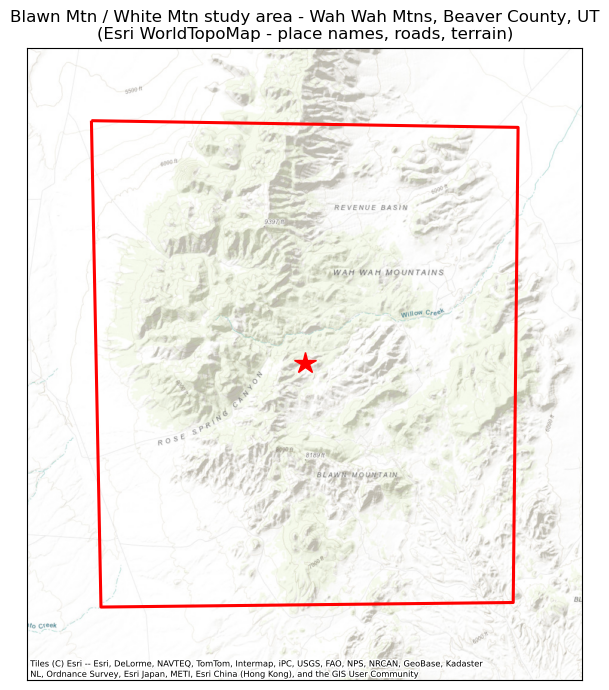

In [ ]:
# Study-area locator over a LABELED topographic basemap (Esri WorldTopoMap): it renders place
# names (towns, mountain ranges, named peaks), roads, and shaded terrain,
# giving the learner geographic context that a bare satellite image does not.
# contextily serves web-mercator (EPSG:3857) tiles, so we reproject the ROI to match.
roi_3857 = roi_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 7))
roi_3857.boundary.plot(ax=ax, color="red", linewidth=2.2, zorder=3)
c = roi_3857.geometry.iloc[0].centroid

# Frame the map to the FULL ROI extent plus a ~15% margin, so the whole polygon is always visible
# with surrounding context (it should match the extent you see opening the GeoJSON in a GIS).
minx, miny, maxx, maxy = roi_3857.total_bounds
padx, pady = 0.15 * (maxx - minx), 0.15 * (maxy - miny)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

try:
    # Esri.WorldTopoMap = named cartographic tiles (place names, roads, contours + hillshade).
    cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap, crs=roi_3857.crs, attribution_size=6)
except Exception as e:
    print("basemap tiles unavailable (offline?) - plotting outline only:", e)

ax.set_title("Southern Pine Valley AOI - southern Wah Wah Range, Beaver County, UT\n"
             "(Esri WorldTopoMap - place names, roads, terrain)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG_DIR / "study_area_basemap.png", dpi=130); plt.show()

# Interactive alternative (uncomment to pan/zoom on a basemap):
# roi_gdf.explore(color="red", style_kwds=dict(fill=False, weight=3), tiles="Esri.WorldTopoMap")

#### The UGS geologic map (OFR-671) of the AOI
The Southern Pine Valley AOI is co-located with the UGS 1:24,000 geologic map **Open-File Report
671**. We load its geologic-unit polygons (`data/ofr-671/.../SouthernPineValleyArea_GeologicUnits.shp`),
clip them to the AOI, and color them by stratigraphic grouping over the topographic basemap. This
gives the spectral analysis a geologic frame: the alunite lithocap and the white-mica alteration
halo we map with EMIT and AVIRIS-5 develop in the **Miocene Blawn Formation** rhyolites (`Tbr`, `Tbm`)
and the surrounding volcanic and sedimentary units shown here, the same rocks that carry the
lithophile critical-metal suite and the UGS geochemistry anomalies.


In [ ]:
# --- OFR-671 geologic units, clipped to the AOI ------------------------------------------------
# The UGS geologic-unit polygons for the Southern Pine Valley area. We clip them to the AOI, then
# draw them colored by stratigraphic `Grouping` over the same Esri topo basemap as the locator
# above, so the learner sees WHICH rocks the spectral targets sit in before any data is loaded.
GEO_DIR = DATA_DIR / "ofr-671"
geo_units_fp = GEO_DIR / "OFR-671DM_SouthernPineValleyArea_Shapefiles" / \
    "SouthernPineValleyArea_GeologicUnits.shp"

geo = gpd.read_file(geo_units_fp).to_crs(epsg=4326)
geo_aoi = gpd.clip(geo, roi_gdf)                      # keep only units within the AOI
geo_aoi_3857 = geo_aoi.to_crs(epsg=3857)              # web-mercator for the basemap

fig, ax = plt.subplots(figsize=(8.5, 7.5))
# Color by stratigraphic grouping (categorical). tab20 gives enough distinct hues for the units.
geo_aoi_3857.plot(ax=ax, column="Grouping", categorical=True, legend=True, cmap="tab20",
                  alpha=0.65, edgecolor="0.3", linewidth=0.3,
                  legend_kwds={"fontsize": 6, "loc": "center left",
                               "bbox_to_anchor": (1.0, 0.5), "title": "Geologic grouping"})
roi_3857.boundary.plot(ax=ax, color="red", linewidth=2.2, zorder=5)

minx, miny, maxx, maxy = roi_3857.total_bounds
padx, pady = 0.06 * (maxx - minx), 0.06 * (maxy - miny)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
try:
    cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap, crs=geo_aoi_3857.crs, attribution_size=6)
except Exception as e:
    print("basemap tiles unavailable (offline?) - plotting units only:", e)
ax.set_title("UGS OFR-671 geologic units over the Southern Pine Valley AOI\n"
             "(clipped to AOI; colored by stratigraphic grouping)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG_DIR / "study_area_geology.png", dpi=130, bbox_inches="tight")
plt.show()

# --- Unit legend / description table (from the OFR-671 attribute table) ------------------------
# The published attribute table is Latin-1 encoded (not UTF-8). We list the units actually present
# in the AOI, joined to their names/ages, so the map above is readable and the Blawn Formation
# rhyolites that host the critical-metal system stand out.
geo_attr = pd.read_csv(GEO_DIR / "OFR-671DM_SouthernPineValley_GeologicUnit_AttributeTable.csv",
                       encoding="latin-1")
units_present = sorted(geo_aoi["UnitSymbol"].dropna().unique())
# Sort stratigraphically by the table's Rank (youngest->oldest), then show the readable columns.
tbl = (geo_attr[geo_attr["UnitSymbol"].isin(units_present)]
       .sort_values("Rank" if "Rank" in geo_attr.columns else "UnitSymbol")
       [["UnitSymbol", "UnitName", "Age", "Grouping"]]
       .reset_index(drop=True))
print(f"Geologic units present in the AOI: {len(units_present)}")
print(tbl.to_string(index=False))
blawn = tbl[tbl["Grouping"].str.contains("Blawn", case=False, na=False)]
if len(blawn):
    print("\nBlawn Formation units in the AOI (host of the lithophile critical-metal suite):")
    print(blawn[["UnitSymbol", "UnitName"]].to_string(index=False))


---
# 2. Find & access EMIT L2B mineralogy (L2BMIN)

Collections used (verified reachable via CMR):

| Product | short_name / concept-id |
|---------|-------------------------|
| EMIT L2B Mineralogy | `EMITL2BMIN` · `C2408034484-LPCLOUD` · DOI 10.5067/EMIT/EMITL2BMIN.001 |
| EMIT L2B Mineralogy Uncertainty | `EMITL2BMINUNCERT` (fit / band-depth uncertainty) |
| EMIT L2A Reflectance | `EMITL2ARFL` · DOI 10.5067/EMIT/EMITL2ARFL.001 |

We search L2BMIN over the ROI. The L2BMIN granule bundles both the MIN and MINUNCERT files,
so we read those asset URLs straight from the granule metadata (`data_links()`). The L2A
reflectance is a separate granule (`EMITL2ARFL`), so we search that collection and match the
granule whose orbit/scene suffix (e.g. `..._2223014_011`) equals our L2BMIN scene's, reliably
pairing the two products without hand-building any URLs. (For product background - instrument,
levels, DOIs - see NASA Earthdata: <https://www.earthdata.nasa.gov/>.)

In [36]:
# --- Search NASA CMR for EMIT L2B mineralogy granules over the ROI -----------------------------
# EMIT L2BMIN ("Estimated Mineral Identification and Band Depth") is the spaceborne mineral-mapping
# product we build section 3 on. We query by the collection's CMR concept-id (a stable handle for
# "this exact product + version") and the ROI polygon, so CMR returns only granules that overlap our
# study area. count=500 is just a safe upper bound on how many results to page back.
EMIT_L2BMIN_CID = "C2408034484-LPCLOUD"

emit_results = earthaccess.search_data(
    concept_id=EMIT_L2BMIN_CID,     # EMIT L2B mineralogy, LP DAAC cloud collection
    polygon=roi_coords,             # CCW ROI vertices from the cell above (CMR wants CCW)
    count=500,                      # max granules to return (we expect far fewer)
)
# Each result is a granule spanning some date/time; the next cells screen these by cloud + season +
# mineral richness to pick the single scene the tutorial analyses.
print(f"EMIT L2BMIN granules over ROI: {len(emit_results)}")

EMIT L2BMIN granules over ROI: 49


### Screen scenes by cloud cover, then match the AVIRIS-5 season - but only among usable scenes

Contrary to a common assumption, EMIT granules do carry a per-granule cloud-cover value. CMR
reports it for every EMIT granule as the standard UMM `CloudCover` field (a scene-average percent,
0-100), which `earthaccess` exposes at `result["umm"]["CloudCover"]`. Because clouds and their
shadows corrupt the retrieved surface reflectance - and therefore the L2BMIN mineral identifications
built on it - we use this field to drop any scene with more than 25% cloud cover before choosing
one to work with.

> Two complementary cloud controls. This scene-level `CloudCover` filter is a coarse first pass
> that rejects mostly-cloudy granules. It does not tell us which pixels are cloudy, so in section 4
> we additionally apply the per-pixel L2A cloud mask to the reflectance. Coarse screen first,
> per-pixel mask second.

Choosing which clear scene to use: require mineral richness first, then match the AVIRIS-5 time of
year. The whole tutorial compares EMIT against the AVIRIS-5 flight line, so ideally the two
platforms see the surface in as similar a state as possible (same snow-free, dry-vegetation,
illumination conditions), which argues for the EMIT scene closest to the AVIRIS day-of-year. But
season is not enough on its own: L2BMIN retrievals vary scene-to-scene, and a clear, well-timed
scene is useless here if EMIT did not actually identify the advanced-argillic / sericitic suite over
the ROI that day. A near-empty scene would collapse the section 3.4 map and the section 6/7
multi-scale comparison. So the selection below applies a mineral-richness gate first, and uses
season only as the tie-break among usable scenes:

1. cloud-screen (drop > 25%);
2. rank the survivors by season (closest to the AVIRIS day-of-year, preferring the same year);
3. walk that ranked list, reading each candidate's L2BMIN and counting how many ROI pixels carry
   an indicator identification (alunite / white mica / kaolinite / dickite / pyrophyllite, in either
   Tetracorder group - raw ID membership, no quality cut);
4. select the first (most season-matched) scene that clears the richness threshold.

The AVIRIS-5 flight date is read from a quick CMR probe of the AVIRIS collection (its granule id
encodes the date). The cell prints the probed shortlist with each scene's indicator count, season
gap, year gap and cloud %, and the day-gap between the chosen scene and the flight, so the whole
decision - richness first, season second - is visible in the output.

> Cost note. The gate downloads the (small, ~40 MB) L2BMIN file for each candidate it probes,
> newest-season-first, and stops at the first rich scene, so it typically reads only a few files. The
> winning scene's L2BMIN is cached, so the download in section 2.x below is a no-op for it.

In [37]:
import datetime as _dt
import re as _re

def granule_name(result):
    # The producer granule id, e.g. EMIT_L2B_MIN_001_20230730T....
    try:
        return result["umm"]["GranuleUR"]
    except Exception:
        return result["meta"]["native-id"]

def cloud_cover(result):
    """Per-granule cloud-cover percent (0-100) from the CMR UMM `CloudCover` field."""
    try:
        return float(result["umm"]["CloudCover"])
    except (KeyError, TypeError, ValueError):
        return np.nan   # treat "unknown" as not-screened-out below

def scene_datetime(result):
    """Acquisition datetime of an EMIT granule, parsed from its granule id timestamp
    (…_YYYYMMDDTHHMMSS_…). Falls back to the CMR temporal start if the id has no timestamp."""
    m = _re.search(r"_(\d{8}T\d{6})_", granule_name(result))
    if m:
        return _dt.datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")
    try:
        s = result["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"]
        return _dt.datetime.fromisoformat(s.replace("Z", "+00:00")).replace(tzinfo=None)
    except Exception:
        return None

def data_urls(result):
    """Asset download URLs straight from the granule metadata (do NOT hand-build URLs)."""
    try:
        return result.data_links()
    except Exception:
        return [u["URL"] for u in result["umm"]["RelatedUrls"] if u.get("Type") == "GET DATA"]

def _gate_download(url, subdir=DATA_DIR):
    """Download `url` unless already present; return the local path. (Same behaviour as the
    cached_download helper defined in the next cell; duplicated here so the richness gate is
    self-contained -- files fetched here are reused, not re-downloaded, downstream.)"""
    dst = Path(subdir) / url.split("/")[-1]
    if dst.exists() and dst.stat().st_size > 0:
        return dst
    print("    downloading", dst.name, "...")
    earthaccess.download([url], local_path=str(subdir))
    return dst

# --- Temporal target: match the EMIT scene to the AVIRIS-5 flight's time of year -----------------
# We want the two platforms to see the most similar surface, so we prefer the EMIT scene closest in
# DAY-OF-YEAR to the AVIRIS-5 acquisition (and the same year). A quick CMR query on the AVIRIS-5 L2A
# collection over the ROI gives us that reference date (from the AVIRIS granule id, which encodes the
# flight date as AV5 + YYYYMMDD). If the search returns nothing we fall back to a late-summer target.
AVIRIS5_L2A_RFL_CID = "C4184090548-ORNL_CLOUD"
try:
    _av_probe = earthaccess.search_data(concept_id=AVIRIS5_L2A_RFL_CID, polygon=roi_coords, count=50)
    _av_dates = []
    for _r in _av_probe:
        _m = _re.search(r"(\d{8})[tT]\d{6}", (_r["umm"]["GranuleUR"] if "umm" in _r else str(_r)))
        if _m:
            _av_dates.append(_dt.datetime.strptime(_m.group(1), "%Y%m%d"))
    if _av_dates:
        AVIRIS_TARGET_DATE = sorted(_av_dates)[len(_av_dates) // 2]   # median flight date
    else:
        raise ValueError("no AVIRIS dates parsed")
except Exception as _e:
    AVIRIS_TARGET_DATE = _dt.datetime(2025, 7, 23)   # known campaign window fallback
    print("AVIRIS date probe unavailable; using fallback target", AVIRIS_TARGET_DATE.date(), f"({_e})")
AVIRIS_TARGET_DOY = AVIRIS_TARGET_DATE.timetuple().tm_yday
print(f"AVIRIS-5 reference date for scene matching: {AVIRIS_TARGET_DATE.date()} "
      f"(day-of-year {AVIRIS_TARGET_DOY})")

# Read the cloud-cover value CMR reports for every EMIT granule over the ROI.
cc = np.array([cloud_cover(r) for r in emit_results])
print("cloud cover reported for {}/{} granules; range {:.0f}-{:.0f}%".format(
    int(np.isfinite(cc).sum()), len(cc),
    np.nanmin(cc) if np.isfinite(cc).any() else float("nan"),
    np.nanmax(cc) if np.isfinite(cc).any() else float("nan")))

# Keep only scenes with <=25% cloud cover (unknown values are kept, not silently dropped).
CLOUD_MAX = 25.0
keep = ~(cc > CLOUD_MAX)
emit_clear = [r for r, k in zip(emit_results, keep) if k]
print(f"granules with <= {CLOUD_MAX:.0f}% cloud cover: {len(emit_clear)} of {len(emit_results)}")

def _doy_gap(dt):
    """Smallest circular day-of-year distance (0-182.5) between a date and the AVIRIS target."""
    if dt is None:
        return 999
    g = abs(dt.timetuple().tm_yday - AVIRIS_TARGET_DOY)
    return min(g, 365 - g)

def season_score(result):
    """Sort key (season gap in days, |year gap|, cloud %) -- lower = closer to the AVIRIS flight."""
    dt = scene_datetime(result)
    season = _doy_gap(dt)
    yeargap = abs(dt.year - AVIRIS_TARGET_DATE.year) if dt is not None else 999
    return (season, yeargap, np.nan_to_num(cloud_cover(result), nan=999))

# --- Mineral-richness gate ----------------------------------------------------------------------
# Matching the season is necessary but NOT sufficient. A clear, well-timed scene is useless for this
# tutorial if EMIT simply did not identify the advanced-argillic / sericitic suite over the ROI that
# day: L2BMIN retrievals vary scene-to-scene with illumination, vegetation, dust and surface
# moisture, and some otherwise-fine scenes carry only a handful of indicator pixels -- which would
# collapse the section 3.4 map and the section 6/7 multi-scale comparison. So we REQUIRE mineral
# richness first, THEN break ties by season:
#   1. rank the cloud-screened scenes by season (closest to the AVIRIS time-of-year first);
#   2. walk down that ranked list, reading each candidate's L2BMIN and counting how many ROI pixels
#      carry an indicator identification (alunite / white mica / kaolinite / dickite / pyrophyllite,
#      in EITHER Tetracorder group), using raw ID membership -- the permissive "did EMIT see this
#      mineral here at all?" test, deliberately with no band-depth/fit cut;
#   3. SELECT the first (most season-matched) scene that clears a richness threshold.
# The result is both usable AND as seasonally close as the data allow, and it is transparent: the
# printed shortlist shows each probed candidate's indicator count next to its season gap.
RICHNESS_MIN = 500          # min ROI pixels carrying any indicator ID for a scene to be usable
MAX_PROBE = 8               # cap how many candidates we download+probe (season-matched first)

# Library indices (into the L2BMIN mineral_id integers) for the indicator suite, built here from the
# EMIT mineral grouping matrix so the gate is self-contained (section 3.2 re-derives the same map for
# the thresholded analysis).
_gate_matrix = pd.read_csv(DATA_DIR / "mineral_grouping_matrix_20230503.csv")
def _gate_is_indicator(name):
    n = str(name).lower()
    return any(k in n for k in ("alunite", "dickite", "kaolin", "pyrophyl",
                                "muscovite", "illite", "sericite"))
_gate_ids = [int(i) for i, nm in zip(_gate_matrix["Index"], _gate_matrix["Name"])
             if _gate_is_indicator(nm)]

def indicator_pixel_count(result):
    """Download this scene's L2BMIN, clip to the ROI, and count pixels whose group-1 OR group-2
    mineral id is in the indicator suite (raw membership, no quality threshold). Returns an int, or
    -1 if the scene could not be read."""
    try:
        urls = data_urls(result)
        min_u = [u for u in urls if "_L2B_MIN_" in u and u.endswith(".nc")][0]
        fp = _gate_download(min_u)           # cached: probing the winner costs no extra download
        ds = et.emit_xarray(str(fp), ortho=False)
        ds = et.spatial_subset(ds, roi_gdf)
        ds = et.ortho_xr(ds)
        g1 = ds["group_1_mineral_id"].values
        g2 = ds["group_2_mineral_id"].values
        want = np.isin(g1, _gate_ids) | np.isin(g2, _gate_ids)
        return int(np.nansum(want))
    except Exception as e:
        print(f"    could not probe {granule_name(result)}: {e}")
        return -1

# Walk season-ranked candidates, probing indicator richness until one clears the bar.
ranked = sorted(emit_clear, key=season_score)
print(f"\nProbing scenes (season-matched first) for indicator richness -- need >= {RICHNESS_MIN} "
      f"ROI pixels with an indicator ID:")
sel_result = None
_shortlist = []
for r in ranked[:MAX_PROBE]:
    dt = scene_datetime(r)
    s, y, c = season_score(r)
    n_ind = indicator_pixel_count(r)
    _shortlist.append((r, dt, s, y, c, n_ind))
    flag = "OK" if n_ind >= RICHNESS_MIN else ("sparse" if n_ind >= 0 else "unreadable")
    print(f"  {granule_name(r):52s} {str(dt.date()) if dt else '????':>10}  "
          f"season {s:>3.0f} d, yr {y}, {c:4.0f}% cloud  ->  {n_ind:>6} indicator px  [{flag}]")
    if n_ind >= RICHNESS_MIN:
        sel_result = r
        break

# Fallback: if none of the probed candidates cleared the bar, take the richest one we saw.
if sel_result is None:
    readable = [t for t in _shortlist if t[5] >= 0]
    if not readable:
        raise RuntimeError("No EMIT scene over the ROI could be read for the richness gate.")
    best = max(readable, key=lambda t: t[5])
    sel_result = best[0]
    print(f"\nNo scene reached {RICHNESS_MIN} indicator px within the first {MAX_PROBE} candidates; "
          f"falling back to the richest one probed ({best[5]} px).")

sel_name = granule_name(sel_result)
names = [granule_name(r) for r in emit_clear]
sel_idx = names.index(sel_name)
_sel_dt = scene_datetime(sel_result)
_sel_season, _sel_year, _sel_cloud = season_score(sel_result)
_day_gap = abs((_sel_dt - AVIRIS_TARGET_DATE).days) if _sel_dt else None
print(f"\nSelected: {sel_name}")
print(f"  acquired {_sel_dt.date() if _sel_dt else '?'}  |  {cloud_cover(sel_result):.0f}% cloud  |  "
      f"{_day_gap} days from the AVIRIS-5 flight  |  season gap {_sel_season:.0f} d, year gap {_sel_year}")
print("  (chosen as the most season-matched clear scene that actually contains the indicator suite.)")

AVIRIS-5 reference date for scene matching: 2025-07-30 (day-of-year 211)
cloud cover reported for 49/49 granules; range 1-99%
granules with <= 25% cloud cover: 21 of 49

Probing scenes (season-matched first) for indicator richness -- need >= 500 ROI pixels with an indicator ID:
  EMIT_L2B_MIN_001_20250728T202546_2520913_010         2025-07-28  season   2 d, yr 0,    2% cloud  ->       2 indicator px  [sparse]
  EMIT_L2B_MIN_001_20250801T184807_2521312_012         2025-08-01  season   2 d, yr 0,    4% cloud  ->     160 indicator px  [sparse]
  EMIT_L2B_MIN_001_20250801T184819_2521312_013         2025-08-01  season   2 d, yr 0,    9% cloud  ->    6524 indicator px  [OK]

Selected: EMIT_L2B_MIN_001_20250801T184819_2521312_013
  acquired 2025-08-01  |  9% cloud  |  2 days from the AVIRIS-5 flight  |  season gap 2 d, year gap 0
  (chosen as the most season-matched clear scene that actually contains the indicator suite.)


In [38]:
# Read the asset URLs directly from the granule metadata -- do NOT hand-build URLs.
# The L2BMIN *granule* already bundles both the MIN and the MINUNCERT files.
def data_urls(result):
    try:
        return result.data_links()
    except Exception:
        return [u["URL"] for u in result["umm"]["RelatedUrls"] if u.get("Type") == "GET DATA"]

min_assets = data_urls(sel_result)
min_url = [u for u in min_assets if "_L2B_MIN_" in u and u.endswith(".nc")][0]
minunc_url = [u for u in min_assets if "_L2B_MINUNCERT_" in u and u.endswith(".nc")][0]

# The L2A reflectance is a SEPARATE granule (EMITL2ARFL). Find the one whose granule id shares
# this scene's orbit/scene suffix (e.g. '..._2223014_011'), then take its RFL/MASK asset URLs.
scene_suffix = "_".join(sel_name.split("_")[-2:])   # e.g. '2223014_011'
rfl_results = earthaccess.search_data(short_name="EMITL2ARFL", polygon=roi_coords, count=500)
rfl_match = [r for r in rfl_results if granule_name(r).endswith(scene_suffix)][0]
rfl_assets = data_urls(rfl_match)
rfl_url = [u for u in rfl_assets if "_L2A_RFL_" in u and u.endswith(".nc")][0]
mask_url = [u for u in rfl_assets if "_L2A_MASK_" in u and u.endswith(".nc")][0]

for label, u in [("MIN", min_url), ("MINUNCERT", minunc_url), ("RFL", rfl_url), ("MASK", mask_url)]:
    print(f"{label:9s}", u.split('/')[-1])

MIN       EMIT_L2B_MIN_001_20250801T184819_2521312_013.nc
MINUNCERT EMIT_L2B_MINUNCERT_001_20250801T184819_2521312_013.nc
RFL       EMIT_L2A_RFL_001_20250801T184819_2521312_013.nc
MASK      EMIT_L2A_MASK_001_20250801T184819_2521312_013.nc


In [39]:
def cached_download(url, subdir=DATA_DIR):
    '''Download `url` to `subdir` unless already present; return local path.'''
    dst = Path(subdir) / url.split("/")[-1]
    if dst.exists() and dst.stat().st_size > 0:
        print("cached:", dst.name)
        return dst
    print("downloading:", dst.name)
    earthaccess.download([url], local_path=str(subdir))
    return dst

fp_min = cached_download(min_url)
fp_minunc = cached_download(minunc_url)

cached: EMIT_L2B_MIN_001_20250801T184819_2521312_013.nc
cached: EMIT_L2B_MINUNCERT_001_20250801T184819_2521312_013.nc


---
# 3. Review L2BMIN mineral detections over the districts

### How L2BMIN works
EMIT L2BMIN is produced by the Tetracorder expert system (USGS), which matches each pixel's
continuum-removed reflectance against a library of mineral spectra. Each pixel gets up to two
identifications:

- Group 1: the ~1 µm (electronic / Fe) region.
- Group 2: the 2.0-2.5 µm region, where the Al-OH sulfates and phyllosilicates
  (alunite, muscovite, kaolinite, pyrophyllite, dickite) live.

The product stores, per pixel: `group_{1,2}_mineral_id` (an integer index into a spectral library)
and `group_{1,2}_band_depth`. We orthorectify with the `emit_tools` GLT helper, then translate the
integer IDs into mineral names using the library metadata table.

In [40]:
# --- Load the L2BMIN mineralogy cube, clip to the ROI, and orthorectify to lat/lon -------------
# EMIT data ships in raw "sensor" space (a pushbroom array that is not yet map-projected). The three
# emit_tools calls below turn it into a clipped, north-up lat/lon grid, in the order that is cheapest:
#   1. emit_xarray(ortho=False)  -> open the file WITHOUT orthorectifying yet (fast, low memory).
#   2. spatial_subset(roi_gdf)   -> crop to the ROI while still in sensor space, so step 3 only has
#                                   to warp the handful of pixels we care about (not the whole scene).
#   3. ortho_xr()                -> apply EMIT's geometric lookup table (GLT) to warp to lat/lon.
ds_min = et.emit_xarray(str(fp_min), ortho=False)   # open raw (unorthorectified) mineral cube
ds_min = et.spatial_subset(ds_min, roi_gdf)         # crop to ROI first (much faster ortho next)
ds_min = et.ortho_xr(ds_min)                        # warp the clipped subset to a lat/lon grid
print(ds_min)                                       # inspect dims/vars: group_1/2 mineral_id, band_depth, ...

<xarray.Dataset> Size: 4MB
Dimensions:             (latitude: 405, longitude: 453, mineral_name: 294)
Coordinates:
    index               (mineral_name) float64 2kB ...
    record              (mineral_name) float64 2kB ...
  * mineral_name        (mineral_name) object 2kB 'Plastic_Tarp GDS339 Green ...
    url                 (mineral_name) object 2kB ...
    group               (mineral_name) float64 2kB ...
    library             (mineral_name) object 2kB ...
  * latitude            (latitude) float64 3kB 38.4 38.4 38.4 ... 38.18 38.18
  * longitude           (longitude) float64 4kB -113.7 -113.7 ... -113.4 -113.4
    elev                (latitude, longitude) float32 734kB 1.68e+03 ... -9.9...
    spatial_ref         int64 8B 0
Data variables:
    group_1_band_depth  (latitude, longitude) float32 734kB 0.03333 ... -9.99...
    group_1_mineral_id  (latitude, longitude) float32 734kB 45.0 ... -9.999e+03
    group_2_band_depth  (latitude, longitude) float32 734kB 0.05294 ... -9.99...

### 3.1 Mineral-ID to name lookup
`emit_xarray` exposes the L2BMIN library metadata on a `mineral_name` dimension. We build a lookup
table and prepend a synthetic `index 0 = No_Match` row (mineral IDs are 1-based; 0 means "no
identification").

In [41]:
# --- Recover the mineral-name lookup table that the integer mineral ids point into --------------
# L2BMIN does not store mineral NAMES per pixel; it stores integer ids (group_1_mineral_id, etc.)
# that index into a spectral LIBRARY carried as coordinate variables on the file. Here we pull every
# such library coordinate (those defined along the `mineral_name` dimension) into a tidy DataFrame so
# we can map id -> human-readable name later.
min_df = pd.DataFrame(
    {v: ds_min[v].values for v in ds_min.coords if "mineral_name" in ds_min[v].dims}
)
# Id 0 means "No_Match" (EMIT identified no library mineral for that pixel) and is not stored as a
# library row, so we prepend it explicitly at index 0 so positional lookups line up with the ids.
zero_row = {c: (0 if c in ("index",) else ("No_Match" if c == "mineral_name" else np.nan))
            for c in min_df.columns}
min_df.loc[-1] = zero_row                       # add the No_Match row (temporary index -1)
min_df = min_df.sort_index().reset_index(drop=True)   # move it to row 0, renumber cleanly
print(min_df.head())
print("\nlibrary entries:", len(min_df))

   index  record                              mineral_name  \
0    0.0     NaN                                  No_Match   
1    1.0  6858.0          Plastic_Tarp GDS339 Green W1R1Fa   
2    2.0   744.0        Hematite.02+Quartz.98 GDS76 W1R1Ha   
3    3.0   882.0  Goethite WS222 <250um MedGrn W1R1H_ AREF   
4    4.0  5736.0         Goethite0.02+Quartz GDS240 W1R1Ba   

                                                           url  group  library  
0                                                          NaN    NaN      NaN  
1  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Plast...    1.0  splib06  
2  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Hemat...    1.0  sprlb06  
3  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goeth...    1.0  sprlb06  
4  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goeth...    1.0  splib06  

library entries: 295


### 3.2 Select the advanced-argillic / sericitic indicator suite
We pull the alunite / white-mica / kaolin-group / pyrophyllite indices from the EMIT mineral grouping
matrix (`data/mineral_grouping_matrix_20230503.csv`, from `emit-sds-l2b`). This is the lithocap
assemblage relevant to critical-mineral targeting. Note the many alunite variants (K vs Na
end-members, synthetic at different temperatures, ammonio-alunite, and alunite mixed with dickite /
kaolinite / pyrophyllite / muscovite), the "alunites of various types" the assemblage calls for.

In [42]:
# --- Group the raw library minerals into the 5 alteration INDICATOR classes ---------------------
# The spectral library has many named entries (e.g. several alunite compositions, muscovite/illite
# variants). For a readable map we collapse them into 5 alteration-indicator classes that track the
# lithocap zoning: Alunite + Pyrophyllite (advanced argillic / acidic core), White mica + Kaolinite +
# Dickite (argillic / sericitic). We match on substrings of the library `Name` (case-insensitive).
matrix = pd.read_csv(DATA_DIR / "mineral_grouping_matrix_20230503.csv")

# Reference patterns (documentation of what each class captures; the actual matching is in
# classify_name below, which needs ORDERED checks to resolve compound names correctly).
INDICATOR_PATTERNS = {
    "Alunite":      r"alunite",
    "White mica":   r"muscovite|illite|sericite",
    "Kaolinite":    r"kaolin",
    "Dickite":      r"dickite",
    "Pyrophyllite": r"pyrophyl",
}

def classify_name(name):
    """Map one library mineral name to an indicator class, or None if it is not an indicator."""
    n = str(name).lower()
    # Order matters: some library names are COMPOUND (e.g. "muscovite+pyrophyllite"). We check the
    # more diagnostic / less ambiguous minerals first so a mixture is assigned to the right class.
    if "alunite" in n:       return "Alunite"
    if "dickite" in n:       return "Dickite"
    if "kaolin" in n:        return "Kaolinite"
    if "pyrophyl" in n and "musc" not in n: return "Pyrophyllite"   # pure pyrophyllite, not musc+pyr mixes
    if any(k in n for k in ("muscovite", "illite", "sericite")): return "White mica"
    return None

matrix["indicator"] = matrix["Name"].apply(classify_name)   # tag every library row with its class
indicators = matrix.dropna(subset=["indicator"])            # keep only the indicator minerals
print("Indicator library entries by class:")
print(indicators["indicator"].value_counts())
print("\nAlunite variants detected in the library:")
for nm in indicators[indicators.indicator == "Alunite"]["Name"]:
    print("  -", nm)

Indicator library entries by class:
indicator
Alunite         20
White mica      11
Kaolinite        4
Pyrophyllite     3
Dickite          1
Name: count, dtype: int64

Alunite variants detected in the library:
  - Alunite GDS97 K Syn (150C) W2R4Na
  - Alunite GDS96 K Syn (250C) W2R4Na
  - Alunite RES-2 K Syn (450C) W2R4Na
  - Alunite GDS95 Na Syn (150C) W2R4Na
  - Alunite RES-4 Na Syn (300C) W2R4Na
  - Alunite RES-3 Na Syn (450C) W2R4Na
  - Alunite GDS82 Na82 W1R1Bb
  - Alunite+Dickite MV99-6-26b W1R1Fc
  - Alunite GDS83 Na63 W1R1Bb
  - Alunite RES-9 Summitv (400C) W2R4Nb
  - Alunite GDS84 Na03 W2R4Na
  - Alunite RES10 NA56% Syn 450C W2R4Na
  - Alunite RES12 NA78% Syn 450C W2R4NaIS
  - Alunite0.35K+.65Na CU91-217H W2R4Nb
  - Alunite0.73K+.27Na CU91-217D W2R4Na
  - Alunite0.66K+.34Na CU91-217A W2R4Nb
  - Alunite+Pyrophyl SD1093A W1R1Bb
  - Alunite0.5+Kaol_KGa-1 AMX3 W1R1Bb
  - Alunite.5+MuscCU91-250A AMX4 W1R1Ba
  - Alunite_NH4+Jaro NMNH145596A W1R1Bb


### 3.3 Which indicators are actually present in this EMIT scene?
We count how many ROI pixels are identified as each indicator (in either Group 1 or Group 2), after
applying quality thresholds adapted from the `mined-lands` AMD workflow:

- band depth >= 0.02 (drop shallow / noise features), and
- fit >= 0.4 - note the L2B `group_*_fit` (correlation coefficient) is stored scaled by 1/2, so
  we multiply by 2 before thresholding.

In [43]:
# --- Build QUALITY-THRESHOLDED per-class pixel masks --------------------------------------------
# Section 3.4's map should show only CONFIDENT identifications, so beyond "the id is in this class"
# we also require the detection to be strong. Two quality gates from the product + its uncertainty:
#   - band depth  >= BAND_DEPTH_MIN : the absorption feature is actually deep (a real, not faint, id)
#   - fit         >= FIT_MIN        : the library spectrum fit the pixel well (goodness-of-match)
# (Open the MINUNCERT file with the same ortho->clip pipeline used for the mineral cube.)
fp_minunc_ds = et.emit_xarray(str(fp_minunc), ortho=False)
fp_minunc_ds = et.spatial_subset(fp_minunc_ds, roi_gdf)
fp_minunc_ds = et.ortho_xr(fp_minunc_ds)

BAND_DEPTH_MIN = 0.02   # minimum group band depth to trust a detection
FIT_MIN = 0.40          # minimum library-fit quality to trust a detection

# Map every indicator library Index -> its class, so we can test pixel ids by class membership.
id_to_indicator = {}
name_list = min_df["mineral_name"].tolist()
for _, row in indicators.iterrows():
    id_to_indicator[int(row["Index"])] = row["indicator"]   # Index is the integer id used in-product

def indicator_mask(ds, ds_unc, group, indicator):
    """Boolean ROI mask: pixels whose group id is in `indicator` AND pass both quality gates.

    EMIT reports up to two mineral groups per pixel (group_1 = strongest feature, group_2 = a second
    feature); callers OR the two groups so a mineral counts as either the primary or secondary id."""
    ids = ds[f"group_{group}_mineral_id"]
    bd  = ds[f"group_{group}_band_depth"]
    fit = ds_unc[f"group_{group}_fit"] * 2.0   # MINUNCERT stores fit at 1/2 scale; undo it here
    # which pixels carry an id belonging to THIS indicator class:
    want = np.isin(ids.values, [k for k, v in id_to_indicator.items() if v == indicator])
    # which pixels clear BOTH quality gates:
    qual = (bd.values >= BAND_DEPTH_MIN) & (fit.values >= FIT_MIN)
    return want & qual

# Tally confident ROI pixels per class (group 1 OR group 2) as a quick sanity check before mapping.
counts = {}
for ind in ["Alunite", "White mica", "Pyrophyllite", "Kaolinite", "Dickite"]:
    m1 = indicator_mask(ds_min, fp_minunc_ds, 1, ind)
    m2 = indicator_mask(ds_min, fp_minunc_ds, 2, ind)
    counts[ind] = int(np.nansum(m1 | m2))
pd.Series(counts, name="ROI pixels").to_frame()

,ROI pixels
Alunite,1561
White mica,2636
Pyrophyllite,759
Kaolinite,1528
Dickite,19


### 3.4 Map the indicator detections
We build a categorical indicator map: each ROI pixel is colored by the strongest indicator detected
(preferring the deeper of its two band-depth identifications). This is the regional screening
product - where in the districts does EMIT see the lithocap assemblage?

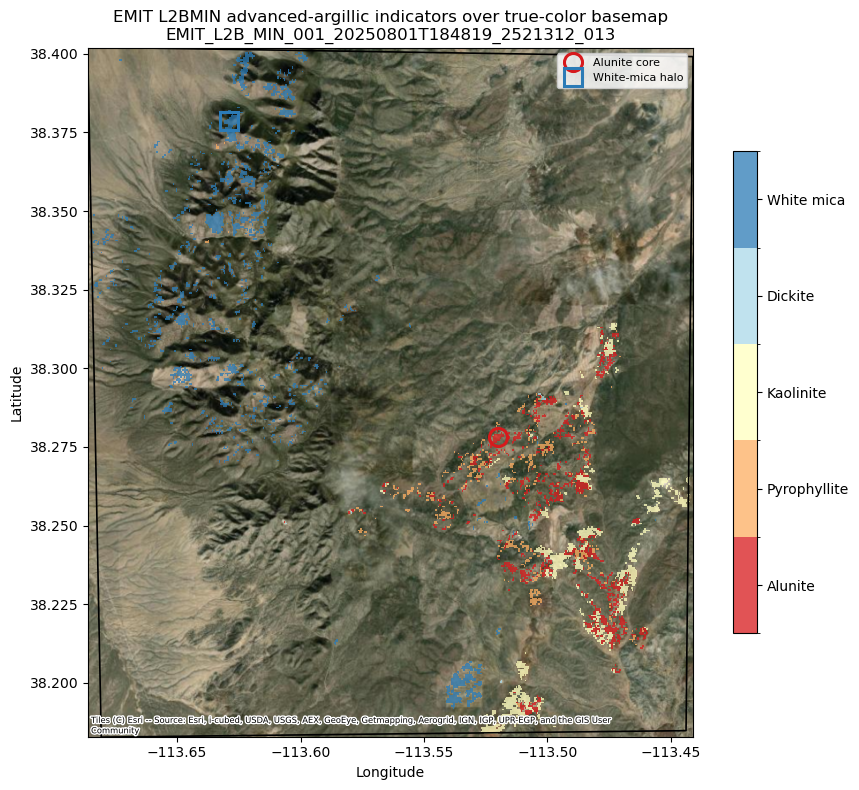

In [44]:
# --- 1. Fix the indicator draw order and give each indicator a fixed color -----------------
# INDICATOR_ORDER also sets the class integer each indicator gets (Alunite=1 ... White mica=5)
# and the acidic -> near-neutral reading order of the colorbar.
INDICATOR_ORDER = ["Alunite", "Pyrophyllite", "Kaolinite", "Dickite", "White mica"]
INDICATOR_COLORS = {
    "Alunite": "#d7191c", "Pyrophyllite": "#fdae61", "Kaolinite": "#ffffbf",
    "Dickite": "#abd9e9", "White mica": "#2c7bb6",
}

# --- 2. Build the categorical indicator raster --------------------------------------------
# For every pixel we keep the SINGLE strongest indicator. EMIT L2BMIN reports up to two mineral
# identifications per pixel (group 1 = deepest feature, group 2 = second feature) each with its own
# band depth; we scan all indicators in both groups and, pixel by pixel, keep whichever detection
# has the largest band depth (`best_bd`). `class_arr` then holds that winning indicator's class
# integer (1..5), or NaN where nothing was detected.
ny, nx = ds_min["group_1_band_depth"].shape
class_arr = np.full((ny, nx), np.nan)   # winning indicator class per pixel (NaN = no detection)
best_bd = np.zeros((ny, nx))            # band depth of the current winner, so we can compare
for ci, ind in enumerate(INDICATOR_ORDER, start=1):
    for group in (1, 2):
        m = indicator_mask(ds_min, fp_minunc_ds, group, ind)            # pixels IDed as this indicator
        bd = np.nan_to_num(ds_min[f"group_{group}_band_depth"].values)  # their feature band depths
        take = m & (bd > best_bd)        # only overwrite where this detection is deeper than the winner
        class_arr[take] = ci
        best_bd[take] = bd[take]

# --- 3. Locate the two spectra-extraction sites for THIS map ------------------------------
# We mark the same two sites shown throughout the notebook (alunite core = red circle, white-mica
# halo = blue square). Sections 4-5 have not run yet, so the flight-line-matched points
# (`alunite_pt_av` / `wmica_pt_av`) do not exist here; instead we pick the scene-wide deepest-band-
# depth pixel for each indicator straight from `class_arr` + `best_bd` above. These are EMIT-derived
# indicator pixels, not independent ground truth, and are the regional-screening counterpart to the
# points refined against the AVIRIS-5 footprint later.
def _scene_site(indicator):
    '''(lat, lon) of the deepest-band-depth pixel that WON its class in `class_arr`.'''
    ci = INDICATOR_ORDER.index(indicator) + 1     # this indicator's class integer
    won = (class_arr == ci)                       # pixels where this indicator is the strongest
    if not won.any():
        return None
    masked_bd = np.where(won, best_bd, -np.inf)   # ignore pixels won by other indicators
    iy, ix = np.unravel_index(np.argmax(masked_bd), masked_bd.shape)
    return (float(ds_min["latitude"].values[iy]), float(ds_min["longitude"].values[ix]))

# (label, (lat, lon), marker, color) -- markers/colors match section 5.1 and the section 6 plot.
SITE_MARKERS_34 = [("Alunite core", _scene_site("Alunite"), "o", "#d7191c"),
                   ("White-mica halo", _scene_site("White mica"), "s", "#2c7bb6")]

# --- 4. Draw the map ----------------------------------------------------------------------
cmap = mcolors.ListedColormap([INDICATOR_COLORS[i] for i in INDICATOR_ORDER])
# BoundaryNorm maps class integers 1..5 onto the 5 discrete colors (bin edges at 0.5,1.5,...,5.5).
norm = mcolors.BoundaryNorm(np.arange(0.5, len(INDICATOR_ORDER) + 1.5), cmap.N)

lon = ds_min["longitude"].values
lat = ds_min["latitude"].values
fig, ax = plt.subplots(figsize=(9, 8))
# Semi-transparent detections (zorder 2) over a true-color basemap (zorder 1), so you can see WHERE
# on the ground (ridges, drainages, disturbance) the lithocap assemblage sits.
pcm = ax.pcolormesh(lon, lat, class_arr, cmap=cmap, norm=norm, shading="auto",
                    alpha=0.75, zorder=2)
roi_gdf.boundary.plot(ax=ax, color="k", linewidth=1.2, zorder=3)   # study-area outline

# Overlay the two spectra-extraction sites on top of everything (zorder 4), using hollow markers so
# the underlying indicator color still shows through.
for label, pt, mk, cl in SITE_MARKERS_34:
    if pt:
        ax.plot(pt[1], pt[0], mk, mfc="none", mec=cl, mew=2.2, ms=13,
                label=label, zorder=4)

ax.set_xlim(lon.min(), lon.max()); ax.set_ylim(lat.min(), lat.max())
try:
    # Esri WorldImagery true-color tiles; crs must match our lon/lat data (EPSG:4326).
    cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs="EPSG:4326",
                   attribution_size=6, zorder=1)
except Exception as e:
    print("basemap tiles unavailable (offline?) - plotting detections only:", e)

# Discrete colorbar: one tick per indicator, labeled in acidic -> near-neutral order.
cbar = fig.colorbar(pcm, ax=ax, ticks=np.arange(1, len(INDICATOR_ORDER) + 1), shrink=0.7)
cbar.ax.set_yticklabels(INDICATOR_ORDER)
# Legend collects the two site markers.
if ax.get_legend_handles_labels()[0]:
    ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax.set_title(f"EMIT L2BMIN advanced-argillic indicators over true-color basemap\n{sel_name}")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.savefig(FIG_DIR / "emit_indicator_map.png", dpi=130); plt.show()

> Interpretation. Alunite (with or without pyrophyllite) marks the acidic advanced-argillic core of
> the lithocap; a white-mica halo around it records the transition to less acidic, near-neutral
> conditions. That acidic to near-neutral zonation is the map-scale fingerprint of the altering
> system that accompanies the lithophile critical-metal enrichment (Be, Li, Mo, Sn, W, REE, U, F) in
> these evolved A-type rhyolites.
>
> Caveat (from the EMIT-Data-Resources L2BMIN documentation): the standard, validated EMIT-10
> mineral groups are robust, but many finer library constituents "require further validation …
> particularly in the case of resource exploration." Treat these detections as indicators to guide
> follow-up, and confirm with the higher-resolution airborne data and, ideally, field/lab work.

---
# 4. Extract EMIT reflectance spectra at indicator sites

The L2BMIN product tells us what mineral; the L2A reflectance shows us the spectrum that led to
that call. We download the matching L2A RFL granule, orthorectify it, and pull spectra at an
alunite-core pixel and a white-mica-halo pixel identified in section 3.

Per-pixel cloud masking. Alongside the reflectance we also download the scene's L2A MASK
granule and apply it. This is the second, finer cloud control promised in section 2: the scene-level
`CloudCover` filter chose a mostly-clear granule, and now the L2A mask removes the individual
cloud pixels within it - cloud, its dilated (buffer) ring, and cirrus - so they cannot leak into
the spectra or the per-pixel maps (including the section 7.2 proxy map, which reads this same masked
reflectance cube).

In [ ]:
fp_rfl = cached_download(rfl_url)
fp_mask = cached_download(mask_url)   # EMIT L2A MASK: the per-pixel quality/cloud flags for this scene

# Build a per-pixel cloud mask from the L2A MASK file, then apply it as we load the reflectance.
# IMPORTANT: the mask file stores its flag bands in `sensor_band_parameters/mask_bands`, and their
# order is not guaranteed, so we look the flags up BY NAME every time rather than by a fixed index.
mask_bands = list(
    xr.open_dataset(str(fp_mask), engine="h5netcdf", group="sensor_band_parameters")["mask_bands"].values
)
print("mask_bands in this file:", mask_bands)

# The buffered cloud mask = Cloud + its Dilated (buffer) + Cirrus. Add "Water flag" /
# "Spacecraft Flag" here if your application needs them.
CLOUD_FLAG_NAMES = ["Cloud flag", "Dilated Cloud Flag", "Cirrus flag"]
cloud_flag_idx = [mask_bands.index(n) for n in CLOUD_FLAG_NAMES]
print("resolved cloud-flag indices:", dict(zip(CLOUD_FLAG_NAMES, cloud_flag_idx)))

qmask = et.quality_mask(str(fp_mask), cloud_flag_idx)   # OR-combines the flags -> 1 = drop pixel
n_flagged = int(np.nansum(qmask))
print(f"cloud-masked pixels: {n_flagged:,} of {qmask.size:,} "
      f"({100*n_flagged/qmask.size:.1f}% of the raw scene)")

# ortho=False first so the raw-space qmask lines up; emit_xarray sets flagged pixels to fill (-9999).
ds_rfl = et.emit_xarray(str(fp_rfl), ortho=False, qmask=qmask)
ds_rfl = et.spatial_subset(ds_rfl, roi_gdf)
ds_rfl = et.ortho_xr(ds_rfl)

# Mask fill values (both the -9999 no-data AND the cloud-flagged pixels set to -9999 above) and
# drop bad bands (deep atmospheric windows) via good_wavelengths.
ds_rfl["reflectance"] = ds_rfl["reflectance"].where(ds_rfl["reflectance"] != -9999)
gw = ds_rfl["good_wavelengths"].values.astype(bool)
ds_rfl["reflectance"].data[:, :, ~gw] = np.nan
wl_emit_um = ds_rfl["wavelengths"].values / 1000.0
print("EMIT bands:", wl_emit_um.shape, "| range um:", round(wl_emit_um.min(), 3), "-", round(wl_emit_um.max(), 3))

cached: EMIT_L2A_RFL_001_20250801T184819_2521312_013.nc
cached: EMIT_L2A_MASK_001_20250801T184819_2521312_013.nc
mask_bands in this file: ['Cloud flag', 'Cirrus flag', 'Water flag', 'Spacecraft Flag', 'Dilated Cloud Flag', 'AOD550', 'H2O (g cm-2)', 'Aggregate Flag']
resolved cloud-flag indices: {'Cloud flag': 0, 'Dilated Cloud Flag': 4, 'Cirrus flag': 1}
Flags used: ['Cloud flag' 'Dilated Cloud Flag' 'Cirrus flag']
cloud-masked pixels: 138,647 of 1,589,760 (8.7% of the raw scene)
EMIT bands: (285,) | range um: 0.381 - 2.493


In [46]:
# --- Locate the two spectra-extraction SITES from the EMIT mineralogy ---------------------------
# The multi-scale comparison (sections 5-7) pulls spectra from one "alunite core" pixel and one
# "white-mica halo" pixel. We define each site as the pixel with the DEEPEST band depth for that
# indicator - i.e. the most spectrally pure, confident example EMIT saw in the ROI.
def pixel_latlon_for(indicator, group_pref=(2, 1)):
    """Return (lat, lon) of the deepest-band-depth pixel for `indicator`, or None if absent.

    We look across both mineral groups (group 2 preferred first, then 1) and keep the single pixel
    with the largest band depth among quality-passing detections."""
    best = None
    for group in group_pref:
        m = indicator_mask(ds_min, fp_minunc_ds, group, indicator)   # quality-passing pixels
        # band depth only where the mask is True, NaN elsewhere, so nanargmax picks a real detection:
        bd = np.where(m, np.nan_to_num(ds_min[f"group_{group}_band_depth"].values), np.nan)
        if np.all(np.isnan(bd)):
            continue                                     # this group has no such indicator here
        iy, ix = np.unravel_index(np.nanargmax(bd), bd.shape)   # row/col of the deepest pixel
        val = bd[iy, ix]
        if best is None or val > best[0]:                # keep the deeper of the two groups
            best = (val, float(ds_min["latitude"].values[iy]),
                    float(ds_min["longitude"].values[ix]))
    return None if best is None else (best[1], best[2])

alunite_pt = pixel_latlon_for("Alunite")       # (lat, lon) of the alunite-core sample site
wmica_pt   = pixel_latlon_for("White mica")    # (lat, lon) of the white-mica-halo sample site
print("alunite-core pixel  (lat, lon):", alunite_pt)
print("white-mica-halo pixel (lat, lon):", wmica_pt)

alunite-core pixel  (lat, lon): (38.27830989712041, -113.52017882957279)
white-mica-halo pixel (lat, lon): (38.378622913367835, -113.6291675661443)


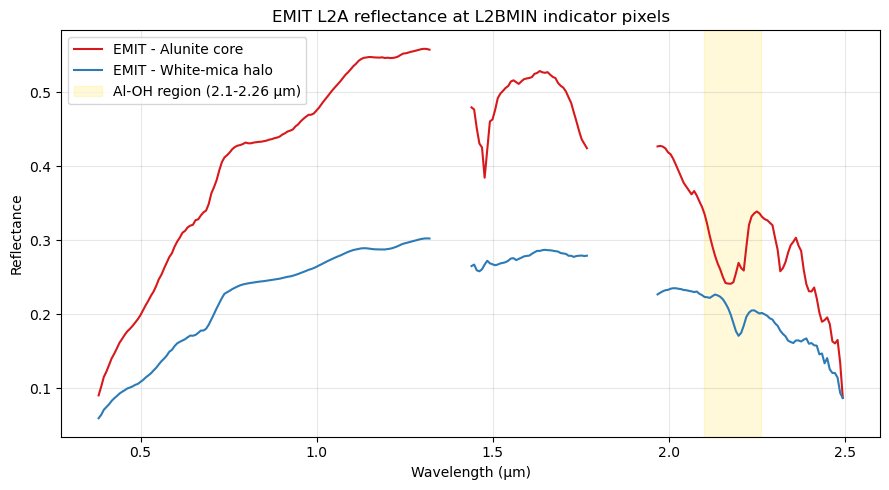

In [47]:
# --- Plot the EMIT reflectance spectra at those two sites ---------------------------------------
# A first look at what the sensor sees at each site. Both alteration indicators have their diagnostic
# Al-OH absorption near 2.2 um, so we shade that region (2.10-2.26 um) - the feature sections 6-7
# analyse in detail. The alunite core and white-mica halo differ subtly in where that dip sits.
def emit_spectrum(lat, lon):
    """Nearest-EMIT-pixel reflectance spectrum at (lat, lon): returns (wavelengths_um, reflectance)."""
    p = ds_rfl.sel(latitude=lat, longitude=lon, method="nearest")   # snap to the closest grid cell
    return wl_emit_um, p["reflectance"].values

fig, ax = plt.subplots(figsize=(9, 5))
for label, pt, color in [("Alunite core", alunite_pt, "#d7191c"),
                          ("White-mica halo", wmica_pt, "#2c7bb6")]:
    if pt is None:
        continue                                          # skip a site the scene did not contain
    w, r = emit_spectrum(*pt)
    ax.plot(w, r, color=color, label=f"EMIT - {label}")
ax.axvspan(2.10, 2.26, color="gold", alpha=0.15, label="Al-OH region (2.1-2.26 µm)")  # diagnostic band
ax.set_xlabel("Wavelength (µm)"); ax.set_ylabel("Reflectance")
ax.set_title("EMIT L2A reflectance at L2BMIN indicator pixels")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "emit_spectra.png", dpi=130); plt.show()

---
# 5. Find & access AVIRIS-5 airborne reflectance (same region)

Now we drop to the airborne scale. AVIRIS-5 (ORNL DAAC) provides orthocorrected surface
reflectance. Because AVIRIS-5 flies on an aircraft, its ground sampling distance (GSD) is a
function of how high the plane is flying - across campaigns it ranges from roughly 0.5 m to
15 m. We will read the GSD of the specific flight line we download straight from its grid
coordinates (section 5, below) rather than assuming a value.

| Product | short_name / concept-id |
|---------|-------------------------|
| AVIRIS-5 L2A Ortho Surface Reflectance | `AV5_L2A_RFL_2484` · `C4184090548-ORNL_CLOUD` · DOI 10.3334/ORNLDAAC/2484 |

> Note: the AVIRIS-5 L1B radiance collection is `C4076410273-ORNL_CLOUD`; for the spectral
> comparison here we need the L2A reflectance collection above.

In [48]:
# --- Search NASA CMR for AVIRIS-5 L2A reflectance granules over the ROI -------------------------
# AVIRIS-5 is the AIRBORNE counterpart to EMIT: same shortwave-infrared spectroscopy, but flown on an
# aircraft at ~10 m ground sampling instead of ~60 m from orbit. Each granule is one flight LINE. We
# query the ORNL DAAC AVIRIS-5 L2A reflectance collection by concept-id + ROI, exactly as we did for
# EMIT, so the rest of the notebook can compare the two sensors over the same ground.
AVIRIS5_L2A_RFL_CID = "C4184090548-ORNL_CLOUD"

aviris_results = earthaccess.search_data(
    concept_id=AVIRIS5_L2A_RFL_CID,   # AVIRIS-5 L2A reflectance, ORNL cloud collection
    polygon=roi_coords,               # same ROI polygon as the EMIT search
    count=500,
)
print(f"AVIRIS-5 L2A RFL granules over ROI: {len(aviris_results)}")
# The airborne section cannot run without at least one line; warn early (rather than failing deep in
# a later cell) if the collection/ROI returns nothing.
if len(aviris_results) == 0:
    print("\n*** No AVIRIS-5 reflectance granules returned for this ROI/time. ***")
    print("The airborne section below requires at least one granule; re-check the ROI or the")
    print("collection concept-id before proceeding.")

AVIRIS-5 L2A RFL granules over ROI: 8


In [49]:
# --- Tabulate the available flight lines (name + acquisition time) ------------------------------
# Print what came back so you can see which flight lines are available and when they were flown,
# before the next cell pins the specific line(s) this tutorial mosaics. Two small accessors read the
# granule name and start time from the CMR metadata (with a fallback for either metadata shape).
def aviris_name(r):
    try:
        return r["umm"]["GranuleUR"]              # the flight-line granule id, e.g. AV520250723t201709_005_...
    except Exception:
        return r["meta"]["native-id"]

def aviris_time(r):
    try:
        return r["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"]   # ISO acquisition start
    except Exception:
        return None

av_table = pd.DataFrame(
    {"granule": [aviris_name(r) for r in aviris_results],
     "time": [aviris_time(r) for r in aviris_results]}
)
print(av_table.head(15).to_string())   # preview the first 15 lines (there may be more)

                            granule                  time
0  AV520250723t163747_010_L2A_RFL_1  2025-07-23T16:54:54Z
1  AV520250723t163747_011_L2A_RFL_1  2025-07-23T16:56:42Z
2  AV520250723t201709_006_L2A_RFL_1  2025-07-23T20:27:04Z
3  AV520250723t201709_007_L2A_RFL_1  2025-07-23T20:28:51Z
4  AV520250730t165108_009_L2A_RFL_1  2025-07-30T17:06:23Z
5  AV520250730t165108_010_L2A_RFL_1  2025-07-30T17:08:11Z
6  AV520250923t204930_006_L2A_RFL_1  2025-09-23T20:57:26Z
7  AV520250923t204930_007_L2A_RFL_1  2025-09-23T20:59:00Z


We pin two adjacent flight lines and mosaic them:
`AV520250723t201709_005_L2A_RFL_1` and `AV520250723t201709_006_L2A_RFL_1`. These two lines from the
same acquisition give the largest combined coverage of the Southern Pine Valley AOI (together they
overlap ~60% of it, far more than any single line), and one line alone clips off part of the
alteration footprint. Both are the same acquisition (same time stamp, consecutive line numbers) in
the same UTM CRS, so they share the wavelength grid and a common easting/northing lattice and tile
together cleanly. If a pinned granule is ever missing the code falls back to the first line whose
footprint contains the alunite-core point from section 4, and finally to the first line returned.
We then download each selected line's reflectance netCDF. AVIRIS-5 reflectance is a NetCDF datatree:
the cube is at `['reflectance']['reflectance']` with `easting`/`northing` map coordinates and a
`wavelength` (singular) coordinate.


In [50]:
def aviris_footprint(r):
    try:
        g = r["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]
        gp = g["GPolygons"][0]["Boundary"]["Points"]
        return shape({"type": "Polygon",
                      "coordinates": [[(p["Longitude"], p["Latitude"]) for p in gp]]})
    except Exception:
        return None

# --- Pin TWO adjacent flight lines and MOSAIC them ------------------------------------------
# These two lines have the most overlap with the Southern Pine Valley AOI (together ~60% of it),
# so the alteration footprint is not clipped by using a single line. Both are the same
# acquisition (…t201709…), consecutive line numbers (_005, _006), so they share
# the sensor's wavelength grid and map CRS and tile together cleanly. We select BOTH and mosaic
# them into one cube (cells below). We match on the granule-name STEM (prefix) so a trailing
# product-version suffix on the GranuleUR still matches.
AVIRIS_LINE_IDS = ["AV520250723t201709_005_L2A_RFL_1",
                   "AV520250723t201709_006_L2A_RFL_1"]

sel_av_list = []
for line_id in AVIRIS_LINE_IDS:
    match = next((r for r in aviris_results if aviris_name(r).startswith(line_id)), None)
    if match is None:
        print(f"WARNING: pinned line {line_id!r} not found in the AVIRIS-5 search results.")
    else:
        sel_av_list.append(match)

# Fallback: if NEITHER pinned line is present (collection re-versioned, ROI changed, ...), drop back
# to the original geometry rule -- the first line whose footprint contains the alunite core -- then
# to the first line returned, so the airborne section still has something to run on.
if not sel_av_list:
    print("Pinned lines unavailable; falling back to footprint-containment selection.")
    target = Point(alunite_pt[1], alunite_pt[0]) if alunite_pt else roi_poly.centroid
    fb = next((r for r in aviris_results
               if aviris_footprint(r) is not None and aviris_footprint(r).contains(target)), None)
    if fb is None and len(aviris_results):
        fb = aviris_results[0]
    if fb is not None:
        sel_av_list = [fb]

# `sel_av` = the primary line (used for figure titles and single-granule fallbacks); `sel_av_list`
# is the full set we will mosaic.
sel_av = sel_av_list[0] if sel_av_list else None
print("selected AVIRIS-5 lines to mosaic:", [aviris_name(r) for r in sel_av_list])

selected AVIRIS-5 lines to mosaic: ['AV520250723t163747_010_L2A_RFL_1', 'AV520250723t163747_011_L2A_RFL_1']


The two mosaicked AVIRIS-5 lines together still cover only part of the ~23 km AOI (a broad
diagonal swath), so the deepest-band-depth alunite-core and white-mica-halo pixels from section 4 must be
re-selected inside the mosaic for an honest same-ground, two-scale comparison. We (1) download
and mosaic the selected lines into one reflectance cube, then (2) re-select a matched pair of
indicator pixels constrained to the mosaicked swath (accepting a pixel if it lies in either
line's footprint).

> Footprint containment is not enough - the pixel must actually have data. A flight line is a
> narrow diagonal strip, but the granule's footprint polygon is a rough bounding quadrilateral, so
> its corners cover ground the sensor never imaged. A point can therefore fall inside the polygon
> yet land on empty (no-data) AVIRIS pixels, which would show up as a flat, meaningless
> "spectrum" in section 6. So the selection below requires both that the EMIT pixel lies in the
> footprint and that the mosaicked AVIRIS cube carries real reflectance there.

These `*_av` points are used for the multi-scale overlays; the scene-wide `alunite_pt` / `wmica_pt`
from section 4 still drive the regional EMIT products.

In [51]:
def aviris_urls(r):
    try:
        return r.data_links()
    except Exception:
        return [u["URL"] for u in r["umm"]["RelatedUrls"] if u.get("Type") == "GET DATA"]

# Download the reflectance netCDF for EVERY selected line (one per granule) so we can mosaic them.
fp_av_list = []
for r in sel_av_list:
    url = [u for u in aviris_urls(r) if u.endswith(".nc") and ("RFL" in u.upper())][0]
    print("downloading:", url.split("/")[-1])
    fp_av_list.append(cached_download(url))

# `fp_av` = the primary line's local path (kept for any single-file reference below).
fp_av = fp_av_list[0]

downloading: AV520250723t163747_010_L2A_OE_da8b3ef7_RFL_ORT.nc
cached: AV520250723t163747_010_L2A_OE_da8b3ef7_RFL_ORT.nc
downloading: AV520250723t163747_011_L2A_OE_da8b3ef7_RFL_ORT.nc
cached: AV520250723t163747_011_L2A_OE_da8b3ef7_RFL_ORT.nc


In [52]:
# =====================================================================================================
# MOSAIC THE SELECTED AVIRIS-5 FLIGHT LINES -- efficiently, with GDAL, and cached to disk.
# =====================================================================================================
# Each AVIRIS-5 reflectance file is ~2.2 GB (424 wavelength bands x ~1400 x ~2100 pixels). Reading two
# of them fully into memory and aligning them pixel-by-pixel (e.g. xarray's combine_first) is very slow
# and needs many GB of RAM. Instead we build a GDAL **virtual raster (VRT)**: a tiny (<1 MB) text file
# that describes how the two flight lines tile together WITHOUT copying any pixel data. GDAL then reads
# only the windows we actually touch (the RGB bands, the pixels around each site), on demand. This is
# the same rasterio/GDAL merge engine the ornl-airborne AVIRIS notebooks use, but as a lazy virtual
# mosaic rather than an eager full-resolution copy.


# Build a cache key from the selected line names so a DIFFERENT choice of lines -> a DIFFERENT
# cache file (never silently reuse a mosaic built from other lines). We take each granule's
# line-number token (e.g. "010") to keep the filename short and stable.
def _line_token(name):
    # granule names look like AV520250723t201709_005_L2A_RFL_1 -> grab the "010" field
    parts = name.split("_")
    return parts[1] if len(parts) > 1 else name
_av_key = "_".join(_line_token(aviris_name(r)) for r in sel_av_list)   # e.g. "010_011"
AV_MOSAIC_VRT = DATA_DIR / f"aviris5_mosaic_{_av_key}.vrt"   # cached virtual-mosaic descriptor

# GDAL addresses a single group/variable inside a NetCDF with the NETCDF:"file":/group/var syntax.
# The reflectance cube lives at /reflectance/reflectance in every AVIRIS-5 L2A file.
av_subdatasets = [f'NETCDF:"{fp}":/reflectance/reflectance' for fp in fp_av_list]

# --- Build (or reuse) the VRT -----------------------------------------------------------------------
# Caching rule: only (re)build the VRT if it does not already exist, so re-running the notebook is
# instant. Delete data/aviris5_mosaic.vrt by hand if you ever change which lines are mosaicked.
if AV_MOSAIC_VRT.exists():
    print("cached VRT:", AV_MOSAIC_VRT.name)
else:
    print("building VRT mosaic from:", [s.split('"')[1].split('/')[-1] for s in av_subdatasets])
    # srcNodata/VRTNodata = -9999 (the AVIRIS fill value): tells GDAL that fill pixels are transparent,
    # so in the overlap between the two lines a real pixel from one line is kept instead of the other
    # line's fill (effectively first-valid-wins), and so rioxarray can later mask -9999 -> NaN for us.
    gdal.BuildVRT(str(AV_MOSAIC_VRT), av_subdatasets, srcNodata=-9999, VRTNodata=-9999).FlushCache()
    print("wrote", AV_MOSAIC_VRT.name, f"({AV_MOSAIC_VRT.stat().st_size/1e3:.0f} KB)")

# --- The wavelength axis (VRT bands are just numbered 1..424; recover the actual wavelengths) --------
# GDAL sees the 424 spectral bands as anonymous raster bands, so we read the real per-band wavelengths
# straight from the first source file (identical across lines from the same acquisition).
av_wl_nm = xr.open_datatree(str(fp_av_list[0]), engine="h5netcdf")\
             .reflectance.to_dataset()["reflectance"]["wavelength"].values

# --- Open the mosaic lazily -------------------------------------------------------------------------
# masked=True applies the -9999 nodata as NaN; chunks=... keeps it lazy (dask) so nothing is read until
# a .sel()/.values below actually needs those pixels. rioxarray names the dims band/y/x; we rename to
# the AVIRIS conventions (wavelength/northing/easting) the rest of the notebook already expects.
av_rfl = (rxr.open_rasterio(str(AV_MOSAIC_VRT), masked=True, chunks={"band": -1, "x": 512, "y": 512})
          .rename({"band": "wavelength", "x": "easting", "y": "northing"})
          .assign_coords(wavelength=av_wl_nm))
av_crs_wkt = av_rfl.rio.crs.to_wkt()          # UTM CRS carried through the VRT from the source files

# --- Trim the lazy mosaic to the ROI (+small pad) ---------------------------------------------------
# The two full lines span the flight corridor but our AOI is a slice of that. We clip the (still lazy)
# cube to the AOI bounding box in the AVIRIS UTM CRS, so the one-time full-extent RGB read in section 5.1 and
# every downstream slice work over the ROI only -- not the whole flight corridor. This is a coordinate
# slice (no data read yet); nodata beyond a line's edge stays NaN.
_roi_utm = roi_gdf.to_crs(av_crs_wkt).total_bounds        # (minx, miny, maxx, maxy) in metres
_pad = 300.0                                              # metres of margin around the ROI
_desc = av_rfl["northing"].values[0] > av_rfl["northing"].values[-1]   # northing descending?
av_rfl = av_rfl.sel(
    easting=slice(_roi_utm[0] - _pad, _roi_utm[2] + _pad),
    northing=(slice(_roi_utm[3] + _pad, _roi_utm[1] - _pad) if _desc
              else slice(_roi_utm[1] - _pad, _roi_utm[3] + _pad)))     # hi->lo when descending

av_wl_um = su.to_micrometers(av_rfl["wavelength"].values)

# rioxarray returns northing DESCENDING (row 0 = north), which is exactly what the origin="upper" RGB
# in section 5.1 and the descending-northing slice logic in section 6 assume -- no re-sorting needed.
print(f"AVIRIS-5 mosaic (lazy) -> (wavelength, northing, easting) = "
      f"{tuple(av_rfl.sizes[d] for d in ('wavelength', 'northing', 'easting'))}")
print("AVIRIS-5 bands:", av_wl_um.shape,
      "| range um:", round(float(av_wl_um.min()), 3), "-", round(float(av_wl_um.max()), 3))
print("north descending:", bool(av_rfl["northing"].values[0] > av_rfl["northing"].values[-1]))

# Short label for figure titles: list the mosaicked line numbers rather than one granule name.
_av_line_names = [aviris_name(r) for r in sel_av_list]
aviris_mosaic_name = (_av_line_names[0] if len(_av_line_names) == 1
                      else f"mosaic of {len(_av_line_names)} lines: " + ", ".join(_av_line_names))

# --- Read the ACTUAL ground sampling distance (GSD) from the grid coordinates -----------------------
# AVIRIS-5 is airborne, so the GSD depends on how high the plane was flying (typically ~0.5-15 m across
# campaigns). Rather than assume a value, we measure it: easting/northing are in metres (metre-based
# UTM CRS), so the median coordinate step IS the pixel size. Both lines share this grid.
AV_GSD_X = float(np.median(np.abs(np.diff(av_rfl["easting"].values))))
AV_GSD_Y = float(np.median(np.abs(np.diff(av_rfl["northing"].values))))
AV_GSD = round(0.5 * (AV_GSD_X + AV_GSD_Y), 2)    # ~identical in x and y; use the mean for labels
print(f"AVIRIS-5 GSD for THIS mosaic: {AV_GSD_X:.2f} m (easting) x {AV_GSD_Y:.2f} m (northing) "
      f"-> {AV_GSD:.1f} m")
print("  (airborne GSD is set by flight altitude; AVIRIS-5 is generally ~0.5-15 m per campaign.)")

cached VRT: aviris5_mosaic_010_011.vrt
AVIRIS-5 mosaic (lazy) -> (wavelength, northing, easting) = (424, 1452, 2183)
AVIRIS-5 bands: (424,) | range um: 0.381 - 2.499
north descending: True
AVIRIS-5 GSD for THIS mosaic: 10.40 m (easting) x 10.40 m (northing) -> 10.4 m
  (airborne GSD is set by flight altitude; AVIRIS-5 is generally ~0.5-15 m per campaign.)


In [53]:
# Footprint used to constrain site selection = the UNION of every mosaicked line's footprint,
# so an indicator pixel is accepted if it falls in EITHER swath (that is the whole point of the
# mosaic: the alunite core and the white-mica halo can fall in different lines).
_av_fps = [fp for fp in (aviris_footprint(r) for r in sel_av_list) if fp is not None]
av_fp = None
for _fp in _av_fps:
    av_fp = _fp if av_fp is None else av_fp.union(_fp)

# The AVIRIS cube (av_rfl) is now loaded, so we can do better than "is the point inside the
# footprint polygon?": a flight line is a narrow DIAGONAL swath, and its bounding polygon contains
# large no-data corners. A point can sit inside the polygon yet land on empty AVIRIS pixels -- which
# would give a flat, meaningless "spectrum" in section 6. So we additionally require the AVIRIS
# reflectance to actually HAVE DATA at the chosen pixel. (Proj is imported at the top of the notebook.)
_av_proj_sel = Proj(av_crs_wkt)
_av_e0, _av_e1 = float(av_rfl["easting"].min()), float(av_rfl["easting"].max())
_av_n0, _av_n1 = float(av_rfl["northing"].min()), float(av_rfl["northing"].max())

def aviris_has_data(lat, lon, min_valid_frac=0.5):
    """True if the nearest AVIRIS pixel to (lat,lon) carries real reflectance (not fill)."""
    x, y = _av_proj_sel(lon, lat)
    if not (_av_e0 <= x <= _av_e1 and _av_n0 <= y <= _av_n1):
        return False                       # outside the data grid entirely
    r = av_rfl.sel(easting=x, northing=y, method="nearest").values.astype("float64")
    return np.mean(np.isfinite(r) & (r > 0)) >= min_valid_frac

def pixel_latlon_in(indicator, footprint, group_pref=(2, 1)):
    """Deepest-band-depth EMIT pixel for an indicator that ALSO has valid AVIRIS data
    (so the same-ground, two-scale comparison in section 6 is real, not empty)."""
    best = None
    for group in group_pref:
        m = indicator_mask(ds_min, fp_minunc_ds, group, indicator)
        bd = np.where(m, np.nan_to_num(ds_min[f"group_{group}_band_depth"].values), np.nan)
        if np.all(np.isnan(bd)):
            continue
        # Walk pixels deepest -> shallowest; take the deepest that is inside the footprint AND
        # has real AVIRIS reflectance under it.
        order = np.argsort(np.nan_to_num(bd.ravel(), nan=-1))[::-1]
        for flat in order:
            val = bd.ravel()[flat]
            if not np.isfinite(val):
                break                       # remaining pixels are all no-data for this indicator
            iy, ix = np.unravel_index(flat, bd.shape)
            la = float(ds_min["latitude"].values[iy]); lo = float(ds_min["longitude"].values[ix])
            if footprint is not None and not footprint.contains(Point(lo, la)):
                continue
            if not aviris_has_data(la, lo):
                continue                     # inside the footprint but on empty AVIRIS pixels -> skip
            best = (val, la, lo)
            break
        if best is not None:
            break
    return None if best is None else (best[1], best[2])

alunite_pt_av = pixel_latlon_in("Alunite", av_fp)
wmica_pt_av = pixel_latlon_in("White mica", av_fp)
for lbl, pt in [("alunite-core", alunite_pt_av), ("white-mica-halo", wmica_pt_av)]:
    if pt is None:
        print(f"WARNING: no {lbl} pixel with both a detection and valid AVIRIS data in this swath.")
    else:
        print(f"{lbl:16s} pixel in swath (lat, lon): {pt}  | AVIRIS data present: {aviris_has_data(*pt)}")

Warning 1: dimension #0 (wavelength) is not a Time or Vertical dimension.
Warning 1: dimension #0 (wavelength) is not a Time or Vertical dimension.


alunite-core     pixel in swath (lat, lon): (38.27830989712041, -113.52017882957279)  | AVIRIS data present: True
white-mica-halo  pixel in swath (lat, lon): (38.34717342719296, -113.63784328646841)  | AVIRIS data present: True


In [54]:
# --- Gather every AVIRIS-5 pixel that falls INSIDE one EMIT pixel -------------------------------
# The whole point of the two-scale comparison: a single ~60 m EMIT pixel covers the same ground as
# MANY ~10.4 m AVIRIS pixels. Below we find all AVIRIS pixels whose centre lands within the EMIT
# pixel footprint centred on a chosen (lat, lon), so sections 6 and 7 can show the spread of AVIRIS
# observations against the single EMIT spectrum.

# EMIT ortho-grid step (degrees) -> the pixel is one grid step wide in lon and lat. We halve it to
# get the footprint half-extent around a pixel centre.
_emit_dlon = float(np.median(np.abs(np.diff(ds_rfl["longitude"].values))))
_emit_dlat = float(np.median(np.abs(np.diff(ds_rfl["latitude"].values))))

# Report the footprint in metres so the learner can see how many AVIRIS pixels to expect inside it.
_mlat = 111_132.0
_mlon = 111_320.0 * np.cos(np.radians(float(np.mean(ds_rfl["latitude"].values))))
_emit_m_ns, _emit_m_ew = _emit_dlat * _mlat, _emit_dlon * _mlon
print(f"EMIT pixel footprint: {_emit_m_ns:.1f} m (N-S) x {_emit_m_ew:.1f} m (E-W)")
print(f"AVIRIS-5 GSD: {AV_GSD:.1f} m  ->  expect ~{round((_emit_m_ns/AV_GSD)*(_emit_m_ew/AV_GSD))} "
      f"AVIRIS pixels per EMIT pixel")

def aviris_pixels_in_emit_footprint(lat, lon):
    """All valid AVIRIS-5 spectra whose pixel centres fall inside the EMIT pixel at (lat, lon).

    Returns (wl_um, R) where R is a (n_pixels, n_bands) array of reflectance with atmospheric
    windows and fill (<=0) set to NaN. These are the many airborne observations that the ONE
    60 m EMIT pixel spatially averages together."""
    # EMIT pixel footprint corners (lat/lon), then project to the AVIRIS map CRS (easting/northing).
    lat0, lat1 = lat - _emit_dlat / 2, lat + _emit_dlat / 2
    lon0, lon1 = lon - _emit_dlon / 2, lon + _emit_dlon / 2
    (x0, y0), (x1, y1) = _av_proj_sel(lon0, lat0), _av_proj_sel(lon1, lat1)
    e_lo, e_hi = min(x0, x1), max(x0, x1)
    n_lo, n_hi = min(y0, y1), max(y0, y1)
    # Slice the AVIRIS cube to that easting/northing box (northing may be descending).
    sub = av_rfl.sel(easting=slice(e_lo, e_hi),
                     northing=slice(n_hi, n_lo) if av_rfl["northing"].values[0] > av_rfl["northing"].values[-1]
                              else slice(n_lo, n_hi))
    if sub["easting"].size == 0 or sub["northing"].size == 0:
        return av_wl_um, np.empty((0, av_wl_um.size))
    # -> (northing*easting, wavelength); mask fill and atmospheric windows; keep pixels with data.
    arr = sub.transpose("northing", "easting", "wavelength").values.reshape(-1, av_wl_um.size).astype("float64")
    arr[arr <= 0] = np.nan
    for lo, hi in [(0.0, 0.45), (1.34, 1.48), (1.80, 1.98), (2.46, 99.0)]:
        arr[:, (av_wl_um >= lo) & (av_wl_um <= hi)] = np.nan
    keep = np.isfinite(arr).mean(axis=1) >= 0.5   # drop no-data pixels in the footprint
    return av_wl_um, arr[keep]

# Quick sanity check: how many AVIRIS pixels actually fall in each site's EMIT footprint?
for lbl, pt in [("alunite-core", alunite_pt_av), ("white-mica-halo", wmica_pt_av)]:
    if pt is not None:
        _, R = aviris_pixels_in_emit_footprint(*pt)
        print(f"{lbl:16s}: {R.shape[0]} valid AVIRIS pixels inside the EMIT footprint")

EMIT pixel footprint: 60.3 m (N-S) x 47.4 m (E-W)
AVIRIS-5 GSD: 10.4 m  ->  expect ~26 AVIRIS pixels per EMIT pixel
alunite-core    : 24 valid AVIRIS pixels inside the EMIT footprint
white-mica-halo : 20 valid AVIRIS pixels inside the EMIT footprint


### 5.1 Look at both datasets before analyzing them - true-color RGB
Before trusting any mineral map or spectrum, look at the imagery. Below we build a true-color RGB
from each sensor's reflectance (red ~ 650 nm, green ~ 560 nm, blue ~ 470 nm) and show them side by
side: the EMIT ~60 m scene (whole ROI) and the AVIRIS-5 10.4 m flight line.

> Where did the clouds go? In the EMIT panel, cloud / dilated-cloud / cirrus pixels are
> now blank (white gaps) - we removed them with the L2A cloud mask in section 4, so they read as
> no-data rather than as bright cloud tops. That is the mask doing its job: those pixels are excluded
> from every downstream product. The AVIRIS-5 panel is not cloud-masked here, so scan it for
> bright white cloud tops and dark cloud/topographic shadow before interpreting it. Remember the two
> sensors were acquired on different dates, so any remaining cloud/shadow patterns differ between
> them, and spectral mineral identifications are only valid over clear, sunlit ground.

cached AVIRIS RGB: aviris5_rgb_roi_010_011.npz


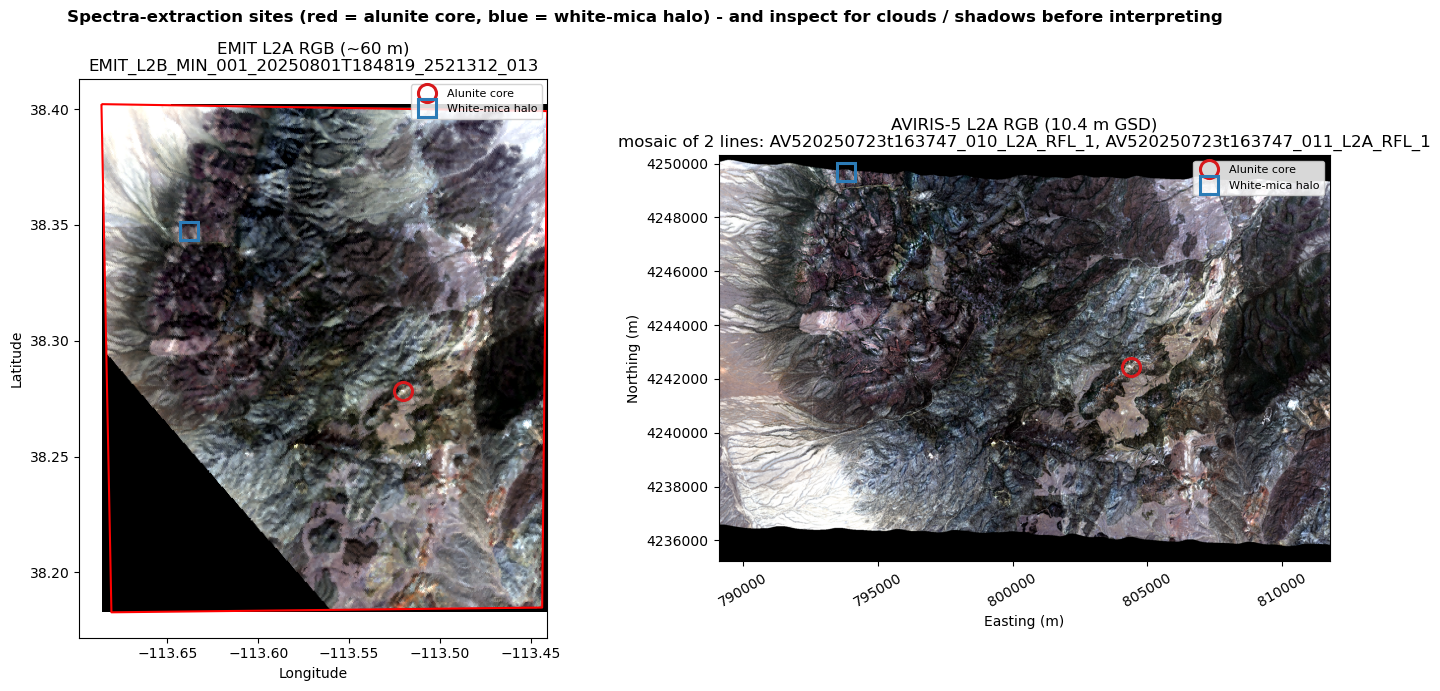

In [55]:
def _stretch(rgb, lo=2, hi=98):
    '''Per-band percentile contrast stretch to [0,1], NaN-safe.

    Raw reflectance values are bunched into a narrow range, so a linear map from [min,max] looks flat.
    We instead map the lo/hi PERCENTILES (2%-98%) to [0,1] and clip, which spreads the mid-tones and
    ignores a few extreme outliers -- the standard "percent-clip" stretch used for display RGBs.'''
    out = np.empty_like(rgb, dtype="float64")
    for b in range(rgb.shape[-1]):                       # stretch each of R, G, B independently
        band = rgb[..., b]
        finite = band[np.isfinite(band)]                 # ignore NaN (no-data / masked) pixels
        if finite.size == 0:
            out[..., b] = 0.0; continue                  # all-NaN band -> render as black
        p_lo, p_hi = np.percentile(finite, [lo, hi])     # the 2nd and 98th percentile values
        out[..., b] = np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)
    return np.nan_to_num(out)                            # NaN -> 0 so imshow draws gaps as black

def _nearest_band(wl_um, target_um):
    '''Index of the band whose wavelength is closest to target_um (bands are not on exact round nm).'''
    return int(np.nanargmin(np.abs(np.asarray(wl_um) - target_um)))

RGB_UM = (0.650, 0.560, 0.470)   # R, G, B target wavelengths (µm) ~ human-visible red / green / blue

# --- EMIT RGB (dims: lat, lon, wavelengths) --------------------------------------------------------
# EMIT is small enough to slice all at once: pick the 3 visible bands and stretch to a display RGB.
emit_rgb_idx = [_nearest_band(wl_emit_um, t) for t in RGB_UM]
emit_rgb = _stretch(ds_rfl["reflectance"].values[:, :, emit_rgb_idx])
emit_lon = ds_rfl["longitude"].values
emit_lat = ds_rfl["latitude"].values

# --- AVIRIS-5 RGB (dims: wavelength, northing, easting) -> (northing, easting, band) ---------------
# CACHING: reading 3 full-extent bands out of the band-interleaved 2.2 GB source files is the one
# unavoidably slow step (~30-60 s the first time), so we compute the stretched RGB ONCE and cache it to
# a small .npz. Every rerun just loads that ~35 MB file in a fraction of a second. Delete the .npz by
# hand if you change the mosaic or the RGB bands.
AV_RGB_CACHE = DATA_DIR / f"aviris5_rgb_roi_{_av_key}.npz"   # keyed on the mosaicked lines (see section 5 mosaic cell)
av_rgb_idx = [_nearest_band(av_wl_um, t) for t in RGB_UM]
if AV_RGB_CACHE.exists():
    print("cached AVIRIS RGB:", AV_RGB_CACHE.name)
    _c = np.load(AV_RGB_CACHE)
    av_rgb, av_east, av_north = _c["rgb"], _c["east"], _c["north"]
else:
    print("computing AVIRIS RGB (one-time full-extent read; will be cached) ...")
    # isel(wavelength=...) reads ONLY the 3 visible bands from the lazy mosaic (not all 424), then we
    # reorder (band, northing, easting) -> (northing, easting, band) for imshow, and stretch.
    av_rgb = _stretch(np.transpose(av_rfl.isel(wavelength=av_rgb_idx).values, (1, 2, 0)))
    av_east = av_rfl["easting"].values
    av_north = av_rfl["northing"].values
    np.savez_compressed(AV_RGB_CACHE, rgb=av_rgb, east=av_east, north=av_north)
    print("wrote", AV_RGB_CACHE.name, f"({AV_RGB_CACHE.stat().st_size/1e6:.0f} MB)")

# The two spectra-extraction pixels used for the section 6 multi-scale plot. These mark WHERE the
# spectra are pulled from (alunite core = red circle, white-mica halo = blue square); they are
# EMIT-derived indicator pixels, not independent ground truth. Same colors/markers as that plot so
# this map is its frame of reference.
SAMPLE_SITES = [("Alunite core", alunite_pt_av, "o", "#d7191c"),
                ("White-mica halo", wmica_pt_av, "s", "#2c7bb6")]

# Transformer to project the sites' (lon, lat) into the AVIRIS-5 UTM CRS for the right-hand panel.
_to_av = Transformer.from_crs("EPSG:4326", av_crs_wkt, always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# EMIT panel (lon/lat axes); overlay the ROI outline and the two sample points.
axes[0].imshow(emit_rgb, origin="upper",
               extent=[emit_lon.min(), emit_lon.max(), emit_lat.min(), emit_lat.max()],
               aspect="auto")
roi_gdf.boundary.plot(ax=axes[0], color="red", linewidth=1.5)
for label, pt, mk, cl in SAMPLE_SITES:
    if pt:                                               # hollow marker so the imagery shows through
        axes[0].plot(pt[1], pt[0], mk, mfc="none", mec=cl, mew=2.2, ms=13, label=label)
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.85)
axes[0].set_title(f"EMIT L2A RGB (~60 m)\n{sel_name}")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# AVIRIS-5 panel (easting/northing in native UTM); origin="upper" because northing is DESCENDING
# (row 0 = north), so the array's first row belongs at the top of the extent.
axes[1].imshow(av_rgb, origin="upper",
               extent=[av_east.min(), av_east.max(), av_north.min(), av_north.max()],
               aspect="equal")
for label, pt, mk, cl in SAMPLE_SITES:
    if pt:
        x, y = _to_av.transform(pt[1], pt[0])            # (lon, lat) -> (easting, northing)
        axes[1].plot(x, y, mk, mfc="none", mec=cl, mew=2.2, ms=13, label=label)
axes[1].legend(loc="upper right", fontsize=8, framealpha=0.85)
axes[1].set_title(f"AVIRIS-5 L2A RGB ({AV_GSD:.1f} m GSD)\n{aviris_mosaic_name}")
axes[1].set_xlabel("Easting (m)"); axes[1].set_ylabel("Northing (m)")
axes[1].ticklabel_format(style="plain", useOffset=False)   # show full UTM metres, not 1e6 offset
axes[1].tick_params(axis="x", labelrotation=30)

fig.suptitle("Spectra-extraction sites (red = alunite core, blue = white-mica halo) - "
             "and inspect for clouds / shadows before interpreting", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR / "emit_aviris_rgb.png", dpi=130); plt.show()

---
# 6. Multi-scale spectral comparison - the core lesson

We extract spectra at the same in-swath alunite-core and white-mica-halo locations selected above
(`alunite_pt_av` / `wmica_pt_av`, the matched pair that falls inside the flight line) and overlay the
two scales.

The key idea, made explicit. One ~60 m EMIT pixel covers the same ground as many ~10.4 m
AVIRIS-5 pixels (~26 of them here). So instead of comparing one EMIT spectrum to a single AVIRIS
spectrum, we plot every AVIRIS pixel that falls inside the EMIT footprint (thin faint lines),
their mean (bold black), and the single EMIT spectrum (bold colour). This shows the learner
two things at once:

- the AVIRIS pixels are not identical - within one 60 m EMIT footprint the surface varies
  (different mineral abundances, illumination, shadow, vegetation), so the airborne spectra spread
  out; and
- the EMIT spectrum tracks roughly the average of that spread, because a coarse pixel
  spatially integrates everything under it. This averaging is the essence of scale: EMIT trades
  spatial detail for global coverage, and the spread you see here is exactly the detail it averages
  away.

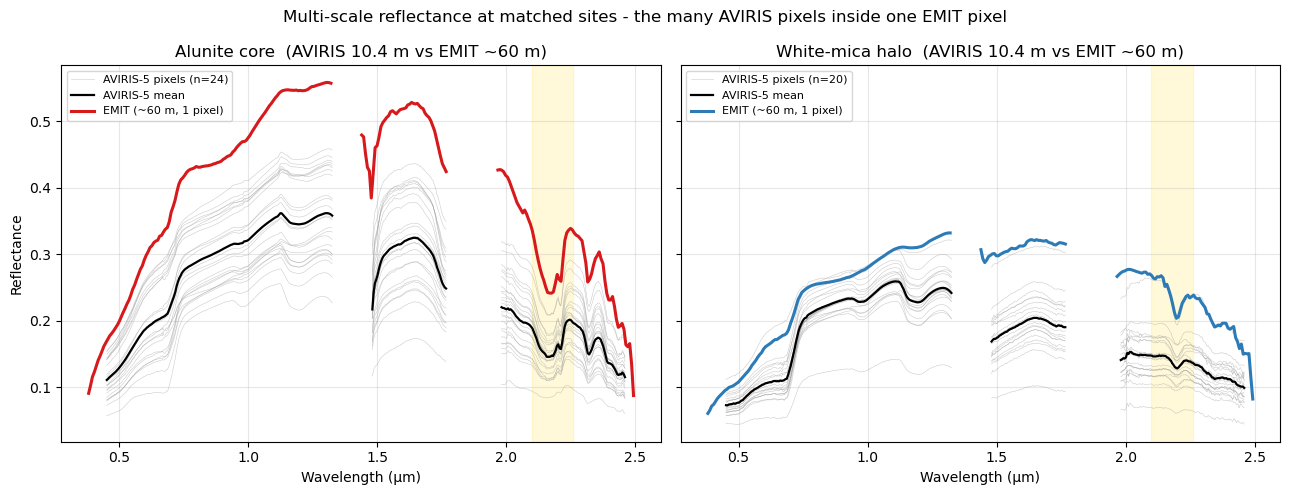

In [56]:
# --- Section 6 figure: the many AVIRIS-5 pixels inside each single EMIT pixel -------------------
# For each site we overlay three things so the SCALE difference is visible:
#   - every ~10 m AVIRIS-5 pixel that falls inside the ~60 m EMIT footprint (thin grey, the spread),
#   - their mean (bold black, what a spatial average of the airborne data looks like), and
#   - the single EMIT pixel (bold colour, what the spaceborne sensor reports for that ground).
av_proj = Proj(av_crs_wkt)   # lon/lat <-> AVIRIS UTM projector (Proj imported at the top of the notebook)

def aviris_spectrum(lat, lon):
    """Single nearest-pixel AVIRIS-5 spectrum (used by the section 7 continuum-removal cell)."""
    x, y = av_proj(lon, lat)                              # project the site to easting/northing
    p = av_rfl.sel(easting=x, northing=y, method="nearest")   # snap to the nearest AVIRIS pixel
    r = p.values.astype("float64")
    r[r <= 0] = np.nan                    # fill / no-data -> NaN
    r = su.bad_band_nan(av_wl_um, r)      # blank out deep atmospheric-absorption windows
    return av_wl_um, r

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (label, pt, color) in zip(
        axes, [("Alunite core", alunite_pt_av, "#d7191c"),
               ("White-mica halo", wmica_pt_av, "#2c7bb6")]):
    if pt is None:
        continue
    # Every AVIRIS-5 pixel inside this EMIT pixel footprint (thin, faint) ...
    wa, R = aviris_pixels_in_emit_footprint(*pt)
    for i in range(R.shape[0]):
        ax.plot(wa, R[i], color="0.6", lw=0.4, alpha=0.5,
                label=f"AVIRIS-5 pixels (n={R.shape[0]})" if i == 0 else None)
    # ... their mean (bold black) ...
    if R.shape[0]:
        ax.plot(wa, np.nanmean(R, axis=0), color="k", lw=1.6, label="AVIRIS-5 mean")
    # ... and the single EMIT pixel (bold colour).
    we, re = emit_spectrum(*pt)
    ax.plot(we, re, color=color, lw=2.2, label="EMIT (~60 m, 1 pixel)")
    ax.axvspan(2.10, 2.26, color="gold", alpha=0.15)     # Al-OH region highlight
    ax.set_title(f"{label}  (AVIRIS {AV_GSD:.1f} m vs EMIT ~60 m)")
    ax.set_xlabel("Wavelength (µm)"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Reflectance")
fig.suptitle("Multi-scale reflectance at matched sites - the many AVIRIS pixels inside one EMIT pixel")
plt.tight_layout(); plt.savefig(FIG_DIR / "multiscale_spectra.png", dpi=130); plt.show()

---
# 7. Diagnosing minerals from absorption features

Raw reflectance is dominated by overall brightness and continuum slope. To read the diagnostic
absorptions we apply continuum removal over the 2.1-2.26 µm Al-OH window and then measure the
feature's position (minimum wavelength) and width (FWHM). These are exactly the parameters
that separate the lithocap minerals (Clark & Roush, 1984; Portela et al., 2025), implemented in
`modules/spectral_utils.py`.

Carrying the multi-pixel idea from section 6 forward, the plot below shows, per site, each individual
AVIRIS-5 pixel inside the EMIT footprint (thin, faint), the mean of those pixels (dashed, bold),
and the single EMIT pixel (solid, bold). The metrics table then reports, for the AVIRIS mean, how
much the fitted Al-OH position varies from pixel to pixel inside that one EMIT footprint - a direct
measure of what the coarse pixel averages away.

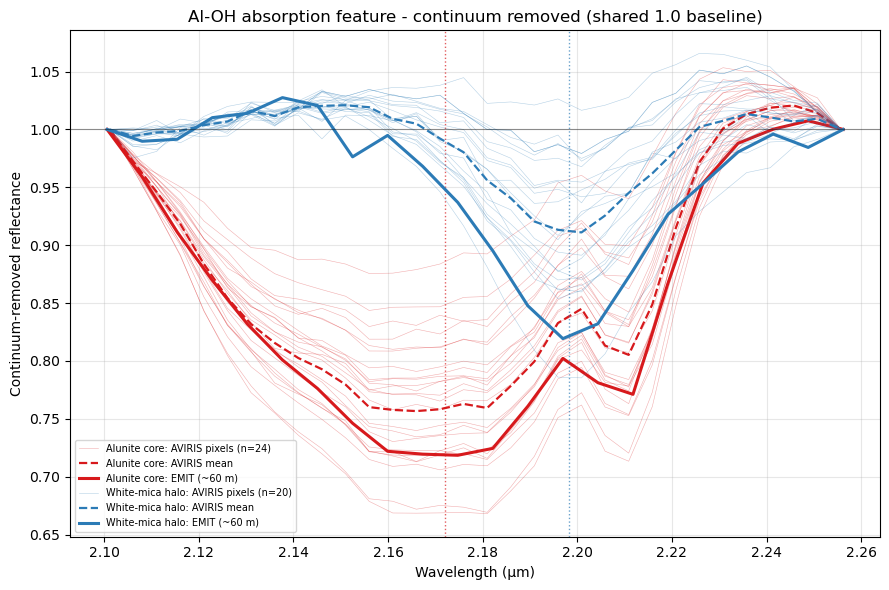

In [57]:
# Plot all continuum-removed spectra on a SHARED baseline (no vertical offset): by construction
# straight-line continuum removal forces both window shoulders to 1.0, so every curve starts and ends
# at ~1.0 and its dip is the true band depth. That common reference lets you read the feature
# POSITION (where each curve bottoms out) and DEPTH directly against each other.
#
# As in section 6 we show, per site: the ONE EMIT pixel (solid, bold), the MEAN of all AVIRIS pixels
# inside that EMIT footprint (dashed, bold), and each individual AVIRIS pixel (thin, faint) so the
# within-footprint spread in feature position/depth is visible.
fig, ax = plt.subplots(figsize=(9, 6))
rows = []

def _cr_line(w_um, r, color, ls, lw, alpha=1.0, label=None):
    cw, cr = su.continuum_removed(w_um, r, wl_range=(2.10, 2.26))
    ax.plot(cw, cr, color=color, lw=lw, ls=ls, alpha=alpha, label=label)

for label, pt, color in [("Alunite core", alunite_pt_av, "#d7191c"),
                          ("White-mica halo", wmica_pt_av, "#2c7bb6")]:
    if pt is None:
        continue
    # Individual AVIRIS pixels in the EMIT footprint (thin, faint) + record their feature positions.
    wa, R = aviris_pixels_in_emit_footprint(*pt)
    av_positions = []
    for i in range(R.shape[0]):
        _cr_line(wa, R[i], color, "-", 0.4, alpha=0.35,
                 label=f"{label}: AVIRIS pixels (n={R.shape[0]})" if i == 0 else None)
        p = su.aloh_feature_metrics(wa, R[i])["min_wavelength_um"]
        if np.isfinite(p):
            av_positions.append(p)
    # AVIRIS mean (dashed, bold).
    if R.shape[0]:
        rmean = np.nanmean(R, axis=0)
        _cr_line(wa, rmean, color, "--", 1.6, label=f"{label}: AVIRIS mean")
        met_av = su.aloh_feature_metrics(wa, rmean)
        rows.append(("AVIRIS-5 mean", label, met_av,
                     np.nanstd(av_positions) if av_positions else np.nan, R.shape[0]))
    # EMIT single pixel (solid, bold).
    we, re = emit_spectrum(*pt)
    _cr_line(su.to_micrometers(we), re, color, "-", 2.2, label=f"{label}: EMIT (~60 m)")
    met_e = su.aloh_feature_metrics(su.to_micrometers(we), re)
    if np.isfinite(met_e["min_wavelength_um"]):
        ax.axvline(met_e["min_wavelength_um"], color=color, ls=":", lw=1, alpha=0.7)
    rows.append(("EMIT", label, met_e, np.nan, 1))

ax.axhline(1.0, color="k", lw=0.8, alpha=0.4)      # the shared continuum reference
ax.set_xlabel("Wavelength (µm)"); ax.set_ylabel("Continuum-removed reflectance")
ax.set_title("Al-OH absorption feature - continuum removed (shared 1.0 baseline)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "continuum_removed.png", dpi=130); plt.show()

In [58]:
# --- Summary table: Al-OH feature metrics per (sensor, site) ------------------------------------
# Turn the feature measurements collected while plotting (the `rows` list from the previous cell) into
# a tidy table. For each EMIT pixel and each AVIRIS-5 footprint mean we report the Al-OH absorption
# POSITION (composition/pH proxy), its DEPTH and width (FWHM). For the AVIRIS means we ALSO report how
# much the position varies pixel-to-pixel within the footprint (spread, in nm) and how many pixels the
# mean is built from - a direct read on how much within-EMIT-pixel heterogeneity the airborne data see.
metrics_df = pd.DataFrame(
    [{"sensor": s, "site": lbl,
      "Al-OH position (µm)": round(m["min_wavelength_um"], 4),
      "band depth": round(m["band_depth"], 3),
      "FWHM (µm)": round(m["fwhm_um"], 4),
      "AVIRIS pos. spread (nm)": (round(pos_std * 1000.0, 1) if np.isfinite(pos_std) else np.nan),
      "n pixels": n}
     for (s, lbl, m, pos_std, n) in rows]   # rows = [(sensor, site, metrics, pos_std, n_pixels), ...]
)
metrics_df

,sensor,site,Al-OH position (µm),band depth,FWHM (µm),AVIRIS pos. spread (nm),n pixels
0,AVIRIS-5 mean,Alunite core,2.1654,0.243,0.0961,7.5,24
1,EMIT,Alunite core,2.1721,0.282,0.0936,NaN,1
2,AVIRIS-5 mean,White-mica halo,2.1991,0.089,0.0328,20.1,20
3,EMIT,White-mica halo,2.1983,0.181,0.0370,NaN,1


### 7.1 Reading the numbers
- Al-OH position near 2.16-2.17 µm -> alunite (advanced argillic, acidic fluids).
- Al-OH position in 2.19-2.21 µm -> white mica; shorter = more Al-rich (higher pH),
  longer = more Al-poor / phengitic (lower pH). This position shift is the fluid-composition
  proxy and the alteration-mapping indicator emphasized by Portela et al. (2025).
- FWHM separates broad alunite from a sharp pyrophyllite feature.

Compare the EMIT row against the AVIRIS-5 mean row for each site: the two scales should recover
consistent feature positions (validating EMIT's regional maps). The AVIRIS pos. spread column
reports the standard deviation (in nm) of the Al-OH position across the individual AVIRIS-5 pixels
inside that one EMIT footprint - i.e. how much the feature actually wanders across the ~26 airborne
pixels the 60 m EMIT pixel lumps together. A small spread means the footprint is spectrally
homogeneous and EMIT's single value is representative; a large spread means EMIT is averaging over a
real mixture that only the airborne scale resolves.

In the plot above, every curve is drawn on the same 1.0 baseline (no vertical offset): straight-line
continuum removal forces both edges of the window to 1.0, so the curves are directly comparable - the
alunite curves bottom out near 2.16-2.17 µm, the white-mica curves shift to ~2.20 µm, and the depth of
each dip is the band depth in the table.

### 7.2 The white-mica composition shift as an image (bonus)
Mapping the Al-OH minimum-wavelength across the scene turns the spectra into a fluid-pH proxy map,
the practical exploration product. We compute it for the white-mica pixels over the ROI. (This runs
the per-pixel feature fit over the ROI subset; for large scenes consider dask/vectorization.)

To make the proxy easy to interpret, we show it as a two-panel figure: on the left we repeat
the section 3.4 indicator-mineralogy map, and on the right the new white-mica fluid-composition
proxy. Both panels cover the same ROI and carry the same two spectra-extraction sites (red circle =
alunite core, blue square = white-mica halo), so you can read the pH gradient directly against
which minerals sit where, and see how the two sample sites relate to both products at once.

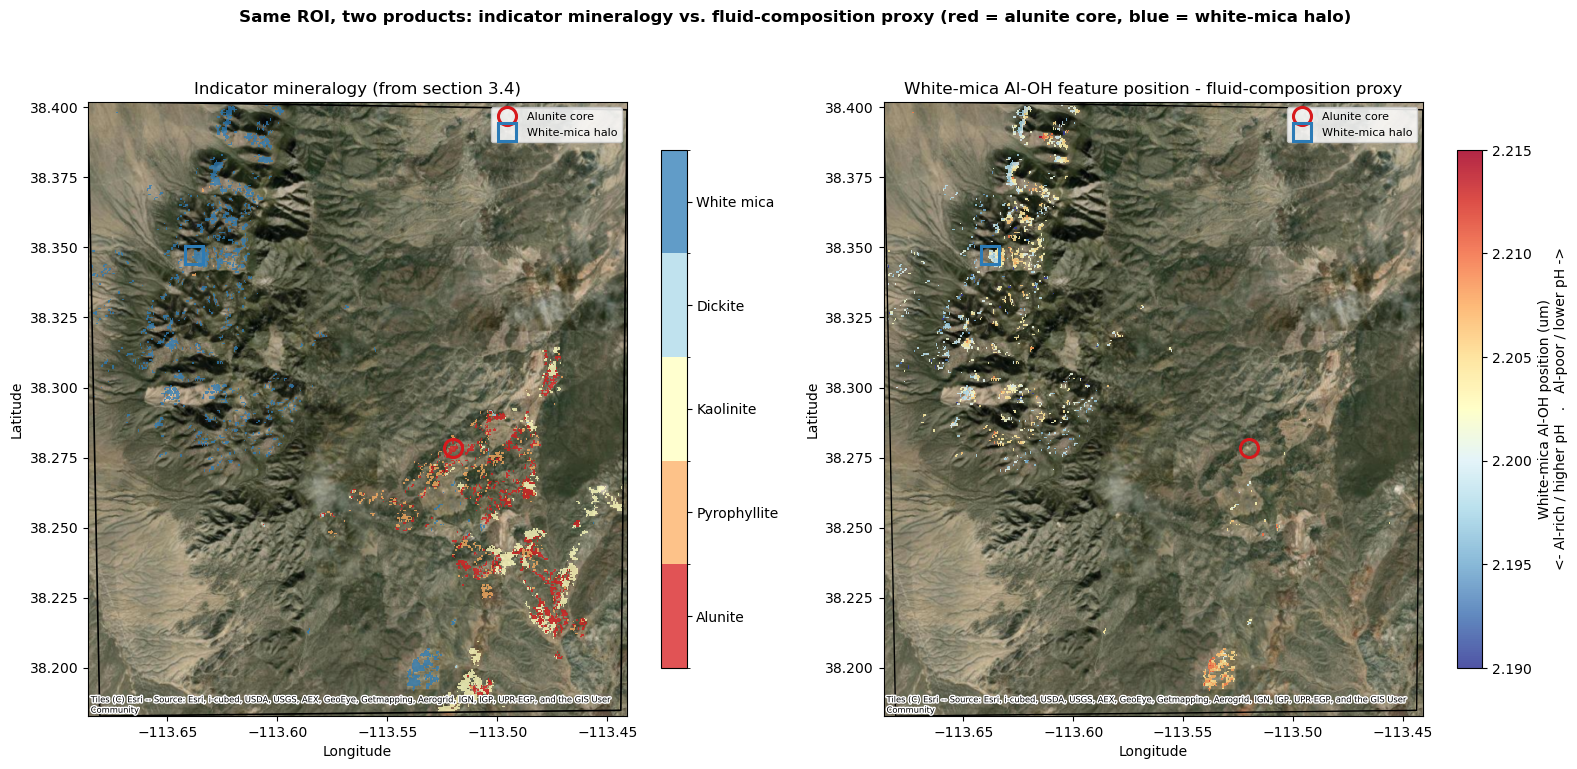

In [59]:
# --- 1. Compute the white-mica Al-OH minimum-wavelength proxy map --------------------------
# For each white-mica pixel we find WHERE (in wavelength) the Al-OH absorption bottoms out between
# 2.10 and 2.26 um. That minimum position shifts with white-mica composition (Al content), which in
# turn tracks fluid pH -- so the map is effectively a fluid-composition / pH proxy.
refl_cube = ds_rfl["reflectance"].values     # (ny, nx, nbands); already cloud-masked in section 4
wl = su.to_micrometers(wl_emit_um)           # band centers in micrometers
in_win = (wl >= 2.10) & (wl <= 2.26)         # the Al-OH search window
wm_map = np.full(refl_cube.shape[:2], np.nan)  # output proxy map (NaN where not computed)

# Restrict the (relatively slow) per-pixel feature fit to white-mica pixels only -- keeps it fast
# and keeps the map interpretable (we only trust the Al-OH position where white mica was detected).
wm_mask = np.zeros(refl_cube.shape[:2], dtype=bool)
for group in (2, 1):
    wm_mask |= indicator_mask(ds_min, fp_minunc_ds, group, "White mica")

# Fit the minimum-wavelength position pixel by pixel over the white-mica mask.
ys, xs = np.where(wm_mask)
for iy, ix in zip(ys, xs):
    spec = refl_cube[iy, ix, :]
    if np.isnan(spec[in_win]).all():          # skip pixels with no valid data in the window
        continue
    wm_map[iy, ix] = su.minimum_wavelength(wl[in_win], spec[in_win], wl_range=(2.10, 2.26))

# --- 2. Site markers -- reuse the exact pair shown in sections 5.1 and 6 -------------------
# alunite core = red circle, white-mica halo = blue square. These are the flight-line-matched
# EMIT-derived pixels (`*_av`), so the same two symbols appear on every multi-scale figure.
SITE_MARKERS_72 = [("Alunite core", alunite_pt_av, "o", "#d7191c"),
                   ("White-mica halo", wmica_pt_av, "s", "#2c7bb6")]

def _overlay_sites(ax):
    '''Draw the two sample sites (hollow markers, on top) onto a lon/lat axis.'''
    for label, pt, mk, cl in SITE_MARKERS_72:
        if pt:
            ax.plot(pt[1], pt[0], mk, mfc="none", mec=cl, mew=2.2, ms=13,
                    label=label, zorder=4)

# --- 3. Two-panel figure: indicator mineralogy (left) vs. fluid-pH proxy (right) -----------
# Left repeats the section 3.4 categorical indicator map; right is the white-mica proxy. Sharing the
# same ROI, basemap and the two site markers lets the reader read the pH gradient directly against
# which minerals are where -- with the two sample sites tying the panels together.
fig, (ax_min, ax_ph) = plt.subplots(1, 2, figsize=(16, 8))

# ---- LEFT PANEL: indicator mineralogy (reuses class_arr / cmap / norm built in section 3.4) ----
pcm_min = ax_min.pcolormesh(lon, lat, class_arr, cmap=cmap, norm=norm, shading="auto",
                            alpha=0.75, zorder=2)
roi_gdf.boundary.plot(ax=ax_min, color="k", linewidth=1.2, zorder=3)
_overlay_sites(ax_min)
ax_min.set_xlim(lon.min(), lon.max()); ax_min.set_ylim(lat.min(), lat.max())
try:
    cx.add_basemap(ax_min, source=cx.providers.Esri.WorldImagery, crs="EPSG:4326",
                   attribution_size=6, zorder=1)
except Exception as e:
    print("basemap tiles unavailable (offline?) -- left panel without basemap:", e)
cbar_min = fig.colorbar(pcm_min, ax=ax_min, ticks=np.arange(1, len(INDICATOR_ORDER) + 1), shrink=0.7)
cbar_min.ax.set_yticklabels(INDICATOR_ORDER)
if ax_min.get_legend_handles_labels()[0]:
    ax_min.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax_min.set_title("Indicator mineralogy (from section 3.4)")
ax_min.set_xlabel("Longitude"); ax_min.set_ylabel("Latitude")

# ---- RIGHT PANEL: white-mica Al-OH position = fluid-composition proxy ----
pcm_ph = ax_ph.pcolormesh(lon, lat, wm_map, cmap="RdYlBu_r", vmin=2.19, vmax=2.215,
                          shading="auto", alpha=0.85, zorder=2)
roi_gdf.boundary.plot(ax=ax_ph, color="k", linewidth=1.0, zorder=3)
_overlay_sites(ax_ph)
ax_ph.set_xlim(lon.min(), lon.max()); ax_ph.set_ylim(lat.min(), lat.max())
try:
    cx.add_basemap(ax_ph, source=cx.providers.Esri.WorldImagery, crs="EPSG:4326",
                   attribution_size=6, zorder=1)
except Exception as e:
    print("basemap tiles unavailable (offline?) -- right panel without basemap:", e)
fig.colorbar(pcm_ph, ax=ax_ph, shrink=0.7,
             label="White-mica Al-OH position (um)\n<- Al-rich / higher pH   .   Al-poor / lower pH ->")
if ax_ph.get_legend_handles_labels()[0]:
    ax_ph.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax_ph.set_title("White-mica Al-OH feature position - fluid-composition proxy")
ax_ph.set_xlabel("Longitude"); ax_ph.set_ylabel("Latitude")

fig.suptitle("Same ROI, two products: indicator mineralogy vs. fluid-composition proxy "
             "(red = alunite core, blue = white-mica halo)", fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR / "white_mica_pH_proxy.png", dpi=130); plt.show()

---
# 8. Synthesis & takeaways

What we did, at two scales:

1. EMIT (spaceborne, ~60 m) - searched and loaded the L2BMIN product over the Southern Pine
   Valley AOI,
   translated Tetracorder mineral IDs into names, and mapped the acidic to near-neutral
   alteration indicator suite (alunites of various K/Na/compound types, pyrophyllite, kaolinite,
   dickite, white mica). This is the regional screening step: where is the lithocap?

2. AVIRIS-5 (airborne, 10.4 m for this flight line) - pulled coincident-region L2A reflectance
   and extracted spectra at the same sites. Because AVIRIS-5 is airborne, its ground sampling
   distance is set by flight altitude (generally ~0.5-15 m across campaigns); this line is 10.4 m,
   so each ~60 m EMIT pixel spans ~26 AVIRIS-5 pixels. This is the outcrop-scale confirmation
   step.

3. Absorption-feature analysis - continuum removal + Al-OH position and width on both
   sensors linked the spectra -> mineralogy -> fluid chemistry:
   - alunite/pyrophyllite ~ 2.16-2.17 µm (acidic, advanced argillic),
   - white mica 2.19-2.21 µm with a position that shifts as a pH / fluid-composition proxy.

The effect of scale, made visible. In sections 6 and 7 we did not compare one EMIT spectrum to one
AVIRIS spectrum - we plotted all the AVIRIS-5 pixels that fall inside a single EMIT footprint. They
are not identical (the surface varies within 60 m), and the single EMIT spectrum tracks roughly their
average. That spread is exactly the sub-pixel detail EMIT trades away for global coverage, and it
is why the airborne scale is needed to confirm and refine the space-based screen.

Why it matters for critical minerals. The alunite lithocap and the surrounding white-mica
composition gradient are surface indicators of the altering system developed in these evolved
A-type rhyolites - the Blawn Formation rhyolites mapped in UGS OFR-671 over this AOI (section 1.1),
the same rocks that carry the lithophile critical-metal suite: Be, Li, Mo, Sn, W, REE, U and F,
with fluorite and REE accessory phases (Lindsey & Osmonson, 1978; Barkoff, 2022). Pairing this
remote screening with the UGS surface geochemistry over the AOI is a natural next step. EMIT screens vast areas cheaply and systematically; airborne AVIRIS-5 confirms
and refines the highest-priority targets. Same physics, two scales.

Extend this notebook:
- Map the alunite Al-OH FWHM to separate alunite- from pyrophyllite-rich zones (Portela decision-tree
  style).
- Add the ~2.32 µm secondary alunite feature and the ~2.35 µm white-mica feature as extra evidence.
- Run the white-mica position map on the full AVIRIS-5 flight line for a high-resolution pH proxy.
- Bring in EMIT L2BMINUNCERT `group_*_fit` as a confidence layer on every product.

### Data citations
- EMIT L2B Mineralogy - DOI 10.5067/EMIT/EMITL2BMIN.001 (LP DAAC).
- EMIT L2A Reflectance - DOI 10.5067/EMIT/EMITL2ARFL.001 (LP DAAC).
- AVIRIS-5 L2A Orthocorrected Surface Reflectance - DOI 10.3334/ORNLDAAC/2484 (ORNL DAAC).
- Geologic map - Utah Geological Survey Open-File Report 671, Southern Pine Valley area, Beaver County, Utah (`data/ofr-671/`).

For background and documentation on EMIT and AVIRIS data products, see NASA Earthdata:
<https://www.earthdata.nasa.gov/>.

### Key references
- Lindsey, D.A. & Osmonson, L.M. (1978), *Mineral potential of altered rocks near Blawn Mountain, Wah
  Wah Range, Utah*, USGS Open-File Report 78-114.
- Barkoff, D.W. (2022), *Trace element behaviors during igneous evolution and hydrothermal alteration
  of an evolved rhyolite, the Blawn Formation, Wah Wah Mountains, Utah*, PhD dissertation, UNLV,
  DOI 10.34917/35777457.
- Portela et al. (2025), *Ore Geology Reviews* 182, 106673.
- Clark, R.N. & Roush, T.L. (1984), *JGR* 89(B7), 6329-6340 (continuum removal).

### Code lineage
`EMIT-Data-Resources` (L2BMIN handling, mineral grouping matrix, `emit_tools`), `VITALS`
(`emit_tools`, coincident airborne/orbital search), `mined-lands` (band-depth / fit thresholding),
`ornl-airborne` (AVIRIS access + netCDF datatree read). Continuum-removal / feature-metric code is
in `modules/spectral_utils.py`.